# 🧪 MLflow — Track, Register, Serve, and Trace ML Models

> **What you'll learn:** how to record every experiment (params, metrics with steps, tags, artifacts), let `autolog` do it for you, compare runs in code, log a *whole* scikit-learn pipeline with a signature, manage versions with registry **aliases** (`champion` / `challenger`), promote models with code, serve a model over real HTTP, evaluate it, and trace a retrieval pipeline span by span.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) (pipelines, train/validation/test splits, metrics) |
| **Tested with** | Python 3.12 · mlflow 3.16 · scikit-learn 1.9 · pandas 3.0 · skops 0.14 |
| **Interview relevance** | ⭐⭐⭐ High — "how do you make experiments reproducible?", params vs metrics vs artifacts, model registry aliases and promotion, serving a model *with* its preprocessing, tracing LLM/RAG pipelines |

## 🤔 What Is MLflow?

Imagine a chemistry lab where nobody keeps a notebook. Someone gets a great result on Tuesday, but on Friday nobody remembers which recipe, which batch of chemicals, or which oven setting produced it. **MLflow is the lab notebook for machine learning** — plus a shelf where the approved recipes live, and a kitchen hatch that serves them.

MLflow is an open-source platform with a few parts that fit together:

| Part | Plain English | You use it to… |
|---|---|---|
| **Tracking** | the lab notebook | record each training **run**: settings (*params*), scores (*metrics*), labels (*tags*), and files (*artifacts*) |
| **Models** | a standard lunchbox for a model | save a model with its environment and input/output **signature**, then load it anywhere |
| **Model Registry** | the shelf of approved recipes | give models names and **versions**, point **aliases** like `champion` at a version |
| **Serving** | the kitchen hatch | run a model as an HTTP API with one command |
| **Evaluation** | the taste test | compute a standard set of metrics and plots for a model |
| **Tracing** | a flight recorder | record every step (**span**) inside an LLM or retrieval pipeline |

```
 train.py ──log──► Tracking server (runs, metrics, artifacts, logged models)
                         │ register
                         ▼
                   Model Registry:  breast-cancer-classifier  v1  v2  v3
                                                              ▲       ▲
                                                     @challenger   @champion
                         │ models:/breast-cancer-classifier@champion
                         ▼
                   mlflow models serve  ──►  POST /invocations  ──►  predictions
```

## 🎯 Why It Matters

- **Reproducibility.** "Which data, code, and hyperparameters produced the model in production?" must have an answer in seconds, not a week of digging.
- **Comparison.** Teams run hundreds of experiments; a searchable record turns "I think C=0.1 was better" into a query.
- **Lineage and safe deployment.** A registered version links back to the run that trained it; aliases let you promote and roll back by moving a pointer instead of copying files.
- **It is everywhere.** MLflow is built into Databricks, available as a managed service on AWS SageMaker and Azure ML, and is the default open-source tracker in many companies. Version 3 added first-class **LoggedModels** and **GenAI tracing**.
- **In interviews** MLOps questions come up in almost every ML engineer loop: *"How do you track experiments?"*, *"How would you promote a new model safely?"*, *"Your served model gives nonsense predictions — what happened?"* (answer: the preprocessing was not packaged with it). This notebook practises all of them with real runs.

## ✅ By the End You Can

- [ ] Explain runs, experiments, params, metrics (with steps), tags, and artifacts — and where each is stored
- [ ] Use `autolog`, `search_runs`, and a file-based tracker you build yourself
- [ ] Log a full preprocessing + model **Pipeline** with a signature and input example, then load it by URI
- [ ] Manage the Model Registry with **aliases**, tags, and descriptions, and write a champion/challenger promotion in code
- [ ] Serve a model with `mlflow models serve`, call it over HTTP, and stop it cleanly
- [ ] Evaluate a model with `mlflow.models.evaluate` and trace a retrieval pipeline with `@mlflow.trace`

## 📋 Table of Contents

1. [Why Experiment Tracking?](#1.-Why-Experiment-Tracking?-🟢)
2. [Where Runs Live: Tracking URIs and Backends](#2.-Where-Runs-Live:-Tracking-URIs-and-Backends-🟢)
3. [Experiments, Runs, Params, Metrics, and Tags](#3.-Experiments,-Runs,-Params,-Metrics,-and-Tags-🟢)
4. [Artifacts: Files Attached to a Run](#4.-Artifacts:-Files-Attached-to-a-Run-🟢)
5. [Autologging scikit-learn](#5.-Autologging-scikit-learn-🟡)
6. [Comparing Runs with `search_runs`](#6.-Comparing-Runs-with-search_runs-🟡)
7. [Logging a Whole Pipeline](#7.-Logging-a-Whole-Pipeline-🟡)
8. [The Model Registry with Aliases](#8.-The-Model-Registry-with-Aliases-🟡)
9. [A Promotion Workflow in Code](#9.-A-Promotion-Workflow-in-Code-🔴)
10. [Serving a Model over HTTP](#10.-Serving-a-Model-over-HTTP-🟡)
11. [Evaluating with `mlflow.models.evaluate`](#11.-Evaluating-with-mlflow.models.evaluate-🟡)
12. [Tracing a Retrieval Pipeline](#12.-Tracing-a-Retrieval-Pipeline-🔴)
13. [The MLflow UI](#13.-The-MLflow-UI-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Reproducible-Model-Competition-on-Adult-Income) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, install it (command in the first comment), then restart the kernel.

- **Where data goes:** everything MLflow writes lives in `_outputs/mlflow/` next to this notebook — a SQLite database for run metadata (`mlflow.db`) and a folder for artifacts. The cell **deletes that folder first**, so version numbers and run counts below are the same every time you run the notebook. (Never do that to a real team's tracking store!)
- **Quiet output:** the cell hides MLflow's INFO chatter and three *known, harmless* messages that come from library internals, each explained in a comment.
- **Datasets:** scikit-learn's built-in breast-cancer table, the 20 Newsgroups text corpus (~14 MB, downloaded once to `~/scikit_learn_data`), and the Adult census table from OpenML (a few MB, cached in the same folder).

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# To install (then restart the kernel):  pip install "mlflow>=3.16" "scikit-learn>=1.8" "pandas>=2.2" skops matplotlib openai

import os

# MLflow 3.16 prints a one-line hint meant for AI coding assistants when it is imported; it is not useful to learners.
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"    # no download progress bars in the saved outputs

import hashlib
import json
import logging
import shutil
import signal
import socket
import subprocess
import sys
import time
import urllib.error
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import sklearn
import skops
import skops.io
from mlflow import MlflowClient
from threadpoolctl import threadpool_limits

print(f"Python {sys.version.split()[0]} | mlflow {mlflow.__version__} | scikit-learn {sklearn.__version__} | "
      f"pandas {pd.__version__} | skops {skops.__version__}")

logging.getLogger("mlflow").setLevel(logging.WARNING)                  # hide INFO lines such as "Creating initial MLflow database tables..."
logging.getLogger("mlflow.utils.environment").setLevel(logging.ERROR)  # this course's venv was made by uv without `pip`, so MLflow can't pin pip in conda.yaml
logging.getLogger("mlflow.models.evaluation.evaluators.classifier").setLevel(logging.ERROR)  # 0/1 integer labels make evaluate() print "model type looks like None"
warnings.filterwarnings("ignore", message="`y_pred` was renamed to `y_proba`", category=FutureWarning)  # MLflow 3.16 autolog uses an old scikit-learn 1.9 argument name
warnings.filterwarnings("ignore", message="Hint: Inferred schema contains integer column", category=UserWarning)  # our integer label column never has missing values

SEED = 42
rng = np.random.default_rng(SEED)
threadpool_limits(limits=4, user_api="openmp")      # cap OpenMP threads: on a busy laptop, one thread per core makes gradient boosting *slower*
OUTPUT_DIR = Path("_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MLFLOW_DIR = (OUTPUT_DIR / "mlflow").resolve()
shutil.rmtree(MLFLOW_DIR, ignore_errors=True)       # fresh, reproducible store for this notebook
MLFLOW_DIR.mkdir(parents=True)
TRACKING_URI = f"sqlite:///{MLFLOW_DIR / 'mlflow.db'}"
ARTIFACT_ROOT = (MLFLOW_DIR / "artifacts").as_uri()
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()                             # lower-level API: registry, run lookups, metric histories


def use_experiment(name):
    """Create the experiment (artifacts under _outputs/mlflow/artifacts/<name>) if needed, then make it active."""
    if mlflow.get_experiment_by_name(name) is None:
        mlflow.create_experiment(name, artifact_location=f"{ARTIFACT_ROOT}/{name}")
    return mlflow.set_experiment(name)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool, set)) or isinstance(a, (str, bool, set)):
            return a == b
        if isinstance(b, dict):
            return isinstance(a, dict) and a.keys() == b.keys() and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)) and any(isinstance(v, (str, dict, type(None))) for v in b):
            return isinstance(a, (list, tuple)) and len(a) == len(b) and all(close(x, e) if e is not None else x is None for x, e in zip(a, b))
        a_arr, b_arr = np.asarray(a), np.asarray(b)
        if a_arr.shape != b_arr.shape:
            return False
        if np.issubdtype(b_arr.dtype, np.number) and np.issubdtype(a_arr.dtype, np.number):
            return bool(np.allclose(a_arr, b_arr, atol=atol, rtol=0))
        return bool(np.array_equal(a_arr, b_arr))

    assert close(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")


print("tracking URI:", TRACKING_URI.replace(str(Path.cwd()), "."))

Python 3.12.11 | mlflow 3.16.0 | scikit-learn 1.9.1 | pandas 3.0.5 | skops 0.14.0


tracking URI: sqlite:///./_outputs/mlflow/mlflow.db


## 1. Why Experiment Tracking? 🟢

An **experiment** in ML is "train a model with some settings and measure it". You will run hundreds. To reproduce or trust any one of them later you need to know:

| What | Example | MLflow calls it |
|---|---|---|
| the settings you chose | `C=0.1`, `max_depth=6` | **params** |
| the scores you measured (maybe per epoch) | `val_auc=0.991` at step 12 | **metrics** |
| labels to find and group runs | `data_sha=3f9c…`, `stage=exploration` | **tags** |
| files produced | plots, reports, the model | **artifacts** |
| *which* data and code | a data fingerprint, a git commit | tags / datasets / source info |

First, let's load a real dataset and split it **once** into train / validation / test. The validation set is for choosing and promoting models; the test set is touched only at the very end.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer(as_frame=True)
X_all, y_all = cancer.data, cancer.target            # 569 tumours × 30 measurements. Careful: 0 = malignant, 1 = benign
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, stratify=y_all, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)
print(f"train {X_train.shape} | validation {X_val.shape} | test {X_test.shape} | classes {cancer.target_names.tolist()}")

# Without tracking, results live only in cell output — gone when the kernel restarts, and missing the "which data?" part.
for C in (0.01, 1.0, 100.0):
    model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=5000)).fit(X_train, y_train)
    print(f"C={C:<6} val AUC {roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]):.4f}")

train (341, 30) | validation (114, 30) | test (114, 30) | classes ['malignant', 'benign']
C=0.01   val AUC 0.9983
C=1.0    val AUC 1.0000
C=100.0  val AUC 0.9934


A cheap way to record **which data** a run used is a *fingerprint*: a hash of the table's contents. Same data → same fingerprint; change one value → a completely different one.

In [3]:
def fingerprint(df):
    """Short content hash of a DataFrame (values + index)."""
    row_hashes = pd.util.hash_pandas_object(df, index=True).to_numpy()
    return hashlib.sha256(row_hashes.tobytes()).hexdigest()[:12]


changed = X_train.copy()
changed.iloc[0, 0] += 0.001
print("train data fingerprint  :", fingerprint(X_train))
print("after changing one value:", fingerprint(changed))
print("same data, same answer  :", fingerprint(X_train) == fingerprint(X_train.copy()))

train data fingerprint  : f75364664862
after changing one value: b91612a6fffb
same data, same answer  : True


### ✍️ Your Turn

Does **row order** affect the fingerprint? Shuffle `X_train` with `X_train.sample(frac=1, random_state=0)` and set `order_matters` to `True` if the fingerprint changes, `False` otherwise.

In [4]:
order_matters = None  # TODO: compare fingerprint(X_train) with the fingerprint of a shuffled copy
check("order_matters", order_matters, True, hint="Compute both fingerprints and compare them with !=.")

⏳ order_matters: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
shuffled = X_train.sample(frac=1, random_state=0)
order_matters = fingerprint(X_train) != fingerprint(shuffled)
check("order_matters", order_matters, True)
```

The per-row hashes are concatenated in order, so a shuffle changes the bytes being hashed. That is usually what you want for a *split* (a different order can mean different mini-batches), but if you only care about the *set* of rows, sort by the index first.
</details>

> 💡 **Interview angle:** "What do you need to reproduce a model?" — code version (git commit), data version (fingerprint / DVC hash / dataset path + snapshot), config (params), environment (package versions), and randomness (seeds). A tracker stores all of it next to the metrics.

## 2. Where Runs Live: Tracking URIs and Backends 🟢

MLflow separates **two stores**:

- **Backend store** — small, structured *metadata*: experiments, runs, params, metrics, tags, registry entries. A database.
- **Artifact store** — big *files*: models, plots, reports. A folder or object storage (S3, GCS, Azure Blob).

The **tracking URI** tells your code where to send everything:

| Tracking URI | When to use it |
|---|---|
| *(not set)* | MLflow 3 creates `sqlite:///mlflow.db` in the current folder (older versions wrote a `./mlruns` folder) |
| `sqlite:///path/mlflow.db` | a single laptop — what this notebook uses |
| `http://mlflow.internal:5000` | a **tracking server** shared by a team; the server talks to Postgres/MySQL and S3 |
| `databricks` | managed MLflow on Databricks |

A team server is started once, e.g.:

```bash
mlflow server --backend-store-uri postgresql://user:pass@db/mlflow \
              --artifacts-destination s3://my-bucket/mlflow --host 0.0.0.0 --port 5000
```

and every engineer sets `export MLFLOW_TRACKING_URI=http://mlflow.internal:5000` — the Python code stays identical.

In [5]:
basics = use_experiment("01-basics")
print("tracking URI     :", mlflow.get_tracking_uri().replace(str(Path.cwd()), "."))
print("experiment       :", basics.name, "| id", basics.experiment_id)
print("artifact location:", basics.artifact_location.replace(Path.cwd().as_uri(), "."))
print("files in the store so far:", sorted(p.name for p in MLFLOW_DIR.iterdir()))

tracking URI     : sqlite:///./_outputs/mlflow/mlflow.db
experiment       : 01-basics | id 1
artifact location: ./_outputs/mlflow/artifacts/01-basics
files in the store so far: ['mlflow.db']


> 💡 **Interview angle:** "How would you set up MLflow for a team of 10?" — one tracking server behind auth, a managed Postgres backend store, S3 artifact store (proxied with `--artifacts-destination` so clients don't need bucket credentials), `MLFLOW_TRACKING_URI` in everyone's environment, and naming/tagging conventions.

## 3. Experiments, Runs, Params, Metrics, and Tags 🟢

- An **experiment** is a folder of related runs (one per project or question).
- A **run** is one execution of training code. Open it with `with mlflow.start_run():` — the `with` block ends the run and marks it `FINISHED`, or `FAILED` if an exception escapes.
- **Params** are inputs, logged once and stored as **strings**; changing a param inside a run is an error.
- **Metrics** are numbers you can log many times with a **step** (epoch, iteration) — that gives you a learning curve.
- **Tags** are free-form string labels you can search on.

Below we train a linear classifier one epoch at a time with `SGDClassifier.partial_fit` and log the training and validation loss after every epoch.

In [6]:
from sklearn.linear_model import SGDClassifier

scaler = StandardScaler().fit(X_train)                     # fitted on training data only
Xs_train, Xs_val = scaler.transform(X_train), scaler.transform(X_val)
sgd_params = {"loss": "log_loss", "alpha": 1e-3, "learning_rate": "constant", "eta0": 0.005, "epochs": 30}

local_val_losses = []                                      # a plain Python copy, to double-check what MLflow stored
with mlflow.start_run(run_name="sgd-epochs") as run:
    mlflow.log_params(sgd_params)
    mlflow.set_tags({"stage": "exploration", "data_sha": fingerprint(X_train)})
    sgd = SGDClassifier(loss="log_loss", alpha=sgd_params["alpha"], learning_rate="constant",
                        eta0=sgd_params["eta0"], random_state=SEED)
    for epoch in range(sgd_params["epochs"]):
        sgd.partial_fit(Xs_train, y_train, classes=[0, 1])
        train_loss = log_loss(y_train, sgd.predict_proba(Xs_train))
        val_loss = log_loss(y_val, sgd.predict_proba(Xs_val))
        mlflow.log_metrics({"train_loss": train_loss, "val_loss": val_loss}, step=epoch)
        local_val_losses.append(val_loss)
    mlflow.log_metric("val_auc", roc_auc_score(y_val, sgd.predict_proba(Xs_val)[:, 1]))
sgd_run_id = run.info.run_id

logged = client.get_run(sgd_run_id)
print("status :", logged.info.status)
print("params :", logged.data.params)
print("tags   :", {k: v for k, v in logged.data.tags.items() if not k.startswith("mlflow.")})
print("metrics:", {k: round(v, 4) for k, v in logged.data.metrics.items()}, "← only the LATEST value per metric")

status : FINISHED
params : {'loss': 'log_loss', 'alpha': '0.001', 'learning_rate': 'constant', 'eta0': '0.005', 'epochs': '30'}
tags   : {'stage': 'exploration', 'data_sha': 'f75364664862'}
metrics: {'train_loss': 0.0728, 'val_loss': 0.0534, 'val_auc': 0.9993} ← only the LATEST value per metric


30 val_loss points stored | identical to our local list: True


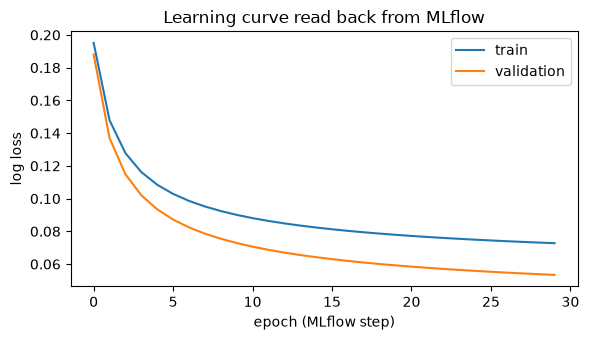

In [7]:
history = client.get_metric_history(sgd_run_id, "val_loss")        # every (step, value) pair
curves = pd.DataFrame({
    "step": [m.step for m in history],
    "val_loss": [m.value for m in history],
    "train_loss": [m.value for m in client.get_metric_history(sgd_run_id, "train_loss")],
})
print(f"{len(history)} val_loss points stored | identical to our local list: {np.allclose(curves.val_loss, local_val_losses)}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(curves.step, curves.train_loss, label="train")
ax.plot(curves.step, curves.val_loss, label="validation")
ax.set(xlabel="epoch (MLflow step)", ylabel="log loss", title="Learning curve read back from MLflow")
ax.legend()
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Using the `history` list from MLflow (not the local list), find the **step with the lowest validation loss** and store it as an `int` in `best_epoch`.

In [8]:
best_epoch = None  # TODO: min over history by m.value, then take m.step
check("best_epoch", best_epoch, int(np.argmin(local_val_losses)), hint="min(history, key=lambda m: m.value).step")

⏳ best_epoch: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_epoch = int(min(history, key=lambda m: m.value).step)
check("best_epoch", best_epoch, int(np.argmin(local_val_losses)))
```

This is exactly what an early-stopping rule or a "pick the best checkpoint" step does: read the curve, not just the last value.
</details>

> 💡 **Interview angle:** "Params vs metrics vs tags?" — params are immutable inputs (strings), metrics are numeric time series keyed by step, tags are mutable string labels for search and workflow state. `run.data.metrics` holds only the latest value; use `get_metric_history` for the curve.

## 4. Artifacts: Files Attached to a Run 🟢

Artifacts are **files** stored with a run: reports, plots, sample predictions, and models. Handy helpers write them for you:

| Helper | Writes |
|---|---|
| `mlflow.log_dict(d, "path.json")` | a dict as JSON or YAML |
| `mlflow.log_text(s, "path.txt")` | a string |
| `mlflow.log_figure(fig, "path.png")` | a Matplotlib figure |
| `mlflow.log_artifact(local_file, artifact_path="folder")` | any existing file |

Read them back with `mlflow.artifacts.load_dict/load_text` or download with `mlflow.artifacts.download_artifacts`.

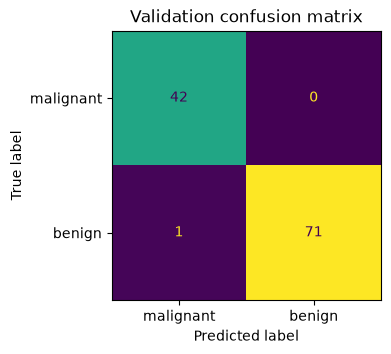

notes/README.txt                              51 bytes
plots/confusion_matrix.png                10,133 bytes
predictions/val_predictions.csv              470 bytes
reports/classification_report.json           601 bytes

macro F1 read back from the artifact: 0.9906
downloaded rows: 114


In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

report_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train, y_train)
val_pred = report_pipe.predict(X_val)

with mlflow.start_run(run_name="artifacts-demo") as run:
    report = classification_report(y_val, val_pred, target_names=list(cancer.target_names), output_dict=True)
    mlflow.log_dict(report, "reports/classification_report.json")
    mlflow.log_text(f"Trained on {len(X_train)} rows; data fingerprint {fingerprint(X_train)}.", "notes/README.txt")

    fig, ax = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay.from_predictions(y_val, val_pred, display_labels=list(cancer.target_names), ax=ax, colorbar=False)
    ax.set_title("Validation confusion matrix")
    mlflow.log_figure(fig, "plots/confusion_matrix.png")
    plt.show()

    predictions_file = OUTPUT_DIR / "val_predictions.csv"
    pd.DataFrame({"y_true": y_val, "y_pred": val_pred}).to_csv(predictions_file, index=False)
    mlflow.log_artifact(str(predictions_file), artifact_path="predictions")
artifacts_run_id = run.info.run_id


def list_all_artifacts(run_id, path=None):
    """Walk the artifact tree of a run."""
    for item in client.list_artifacts(run_id, path):
        if item.is_dir:
            yield from list_all_artifacts(run_id, item.path)
        else:
            yield item.path, item.file_size


for artifact_path, size in list_all_artifacts(artifacts_run_id):
    print(f"{artifact_path:40s} {size:>7,} bytes")

loaded_report = mlflow.artifacts.load_dict(f"runs:/{artifacts_run_id}/reports/classification_report.json")
print("\nmacro F1 read back from the artifact:", round(loaded_report["macro avg"]["f1-score"], 4))
downloaded = mlflow.artifacts.download_artifacts(run_id=artifacts_run_id, artifact_path="predictions",
                                                 dst_path=str(OUTPUT_DIR / "downloaded"))
print("downloaded rows:", len(pd.read_csv(Path(downloaded) / "val_predictions.csv")))

### ✍️ Your Turn

In a **new run**, log the dict `{"n_train": len(X_train), "n_features": X_train.shape[1]}` to the artifact path `meta/data.json`, then load it back with `mlflow.artifacts.load_dict` into `meta_back`.

In [10]:
meta_back = None  # TODO: with mlflow.start_run() as r: mlflow.log_dict(...); then load_dict(f"runs:/{r.info.run_id}/meta/data.json")
check("meta_back", meta_back, {"n_train": 341, "n_features": 30}, hint="The artifact URI looks like runs:/<run_id>/meta/data.json")

⏳ meta_back: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
with mlflow.start_run(run_name="your-turn-artifact") as r:
    mlflow.log_dict({"n_train": len(X_train), "n_features": X_train.shape[1]}, "meta/data.json")
meta_back = mlflow.artifacts.load_dict(f"runs:/{r.info.run_id}/meta/data.json")
check("meta_back", meta_back, {"n_train": 341, "n_features": 30})
```
</details>

> 💡 **Interview angle:** "Where should a 2 GB checkpoint go — a metric, a param, or an artifact?" — an artifact (object storage). Don't log big artifacts every step; log the best/final checkpoint, and log small summaries (JSON, PNG) generously.

## 5. Autologging scikit-learn 🟡

`mlflow.sklearn.autolog()` patches scikit-learn so that every `fit()` inside a run logs for you:

- **params** — every `get_params()` value, including nested pipeline params like `logisticregression__C`
- **training metrics** — accuracy, precision, recall, F1, log loss, ROC AUC on the *training* data (optimistic!)
- **post-training metrics** — when you call `score()` or a `sklearn.metrics` function *inside the run*, it logs that too, named after your variables (e.g. `Pipeline_score_X_val`)
- **artifacts** — `estimator.html`, training confusion matrix, ROC and PR curves; and the model itself unless `log_models=False`
- **hyperparameter search** — `GridSearchCV` / `RandomizedSearchCV` become a parent run with the best params plus child runs for the top candidates (`max_tuning_runs`)

What it does **not** know: which data version you used, your business metric, or anything computed outside the run.

In [11]:
from sklearn.model_selection import GridSearchCV

use_experiment("02-autolog")
mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)   # we log models explicitly in section 7

with mlflow.start_run(run_name="autolog-pipeline") as run:
    auto_pipe = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=5000)).fit(X_train, y_train)
    val_accuracy = auto_pipe.score(X_val, y_val)             # captured as a post-training metric

auto_run = client.get_run(run.info.run_id)
print(f"{len(auto_run.data.params)} params, e.g.:", {k: auto_run.data.params[k] for k in ["logisticregression__C", "standardscaler__with_mean"]})
print("metrics  :", {k: round(v, 4) for k, v in auto_run.data.metrics.items()})
print("artifacts:", [path for path, _ in list_all_artifacts(run.info.run_id)])

23 params, e.g.: {'logisticregression__C': '0.5', 'standardscaler__with_mean': 'True'}
metrics  : {'training_precision_score': 0.9854, 'training_recall_score': 0.9853, 'training_f1_score': 0.9853, 'training_accuracy_score': 0.9853, 'training_log_loss': 0.069, 'training_roc_auc': 0.9953, 'training_score': 0.9853, 'Pipeline_score_X_val': 0.9912}
artifacts: ['estimator.html', 'metric_info.json', 'training_confusion_matrix.png', 'training_precision_recall_curve.png', 'training_roc_curve.png']


In [12]:
with mlflow.start_run(run_name="autolog-grid") as parent:
    grid = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                        {"logisticregression__C": [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring="roc_auc").fit(X_train, y_train)
mlflow.sklearn.autolog(disable=True)                          # switch it off so later cells log only what we ask

autolog_runs = mlflow.search_runs(experiment_names=["02-autolog"])
children = autolog_runs[autolog_runs["tags.mlflow.parentRunId"] == parent.info.run_id]
print("child runs:", len(children))
print(children[["params.logisticregression__C", "metrics.mean_test_score"]].sort_values("metrics.mean_test_score", ascending=False).to_string(index=False))
parent_run = client.get_run(parent.info.run_id)
print("parent best params:", {k: v for k, v in parent_run.data.params.items() if k.startswith("best_")},
      "| best_cv_score:", round(parent_run.data.metrics["best_cv_score"], 4))
print("matches GridSearchCV:", grid.best_params_, round(grid.best_score_, 4))

child runs: 4
params.logisticregression__C  metrics.mean_test_score
                         0.1                 0.993727
                         1.0                 0.992275
                        0.01                 0.989091
                        10.0                 0.980392
parent best params: {'best_logisticregression__C': '0.1'} | best_cv_score: 0.9937
matches GridSearchCV: {'logisticregression__C': 0.1} 0.9937


> 💡 **Interview angle:** "Is autolog enough?" — it's a great default for params and standard artifacts, but its training metrics are on training data, and it can't know your data version or business metric. Combine it with explicit `log_metric` calls on a validation set and tags for data lineage.

## 6. Comparing Runs with `search_runs` 🟡

The UI is nice, but automated pipelines compare runs in **code**. `mlflow.search_runs` returns a pandas DataFrame (or a list of `Run` objects) and accepts:

- `filter_string` — a SQL-like filter: `"params.model_type = 'rf' and metrics.val_auc > 0.99"` (params and tags are compared as **strings**, metrics as numbers)
- `order_by` — e.g. `["metrics.val_auc DESC"]`
- `max_results`, `output_format="list"`

We run seven quick candidates and record the same numbers in a Python list, so we can double-check the query results.

In [13]:
from sklearn.ensemble import RandomForestClassifier

use_experiment("03-compare")
candidates = [("logreg", {"C": C}) for C in (0.01, 0.1, 1.0, 10.0)] + [("rf", {"max_depth": d}) for d in (2, 4, 8)]
leaderboard = []
for model_type, hp in candidates:
    if model_type == "logreg":
        estimator = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, **hp))
    else:
        estimator = RandomForestClassifier(n_estimators=200, n_jobs=4, random_state=SEED, **hp)
    run_name = f"{model_type}-" + "-".join(f"{k}{v}" for k, v in hp.items())
    with mlflow.start_run(run_name=run_name):
        estimator.fit(X_train, y_train)
        proba = estimator.predict_proba(X_val)[:, 1]
        metrics = {"val_auc": roc_auc_score(y_val, proba), "val_accuracy": accuracy_score(y_val, proba >= 0.5)}
        mlflow.log_params({"model_type": model_type, **hp})
        mlflow.log_metrics(metrics)
    leaderboard.append({"run_name": run_name, "model_type": model_type, **metrics})

runs = mlflow.search_runs(experiment_names=["03-compare"], order_by=["metrics.val_auc DESC"])
print(runs[["tags.mlflow.runName", "params.model_type", "metrics.val_auc", "metrics.val_accuracy"]].to_string(index=False))

best_local = max(leaderboard, key=lambda r: r["val_auc"])
print(f"\nbest val_auc from the query {runs['metrics.val_auc'].iloc[0]:.4f} == best in our list {best_local['val_auc']:.4f}:",
      bool(np.isclose(runs["metrics.val_auc"].iloc[0], best_local["val_auc"])))

strong_rf = mlflow.search_runs(experiment_names=["03-compare"], output_format="list",
                               filter_string="params.model_type = 'rf' and metrics.val_accuracy >= 0.95")
print("RF runs with val_accuracy ≥ 0.95:", sorted(r.info.run_name for r in strong_rf))

tags.mlflow.runName params.model_type  metrics.val_auc  metrics.val_accuracy
        logreg-C1.0            logreg         1.000000              0.991228
        logreg-C0.1            logreg         0.999008              0.982456
       logreg-C10.0            logreg         0.998677              0.982456
       logreg-C0.01            logreg         0.998347              0.964912
      rf-max_depth8                rf         0.996362              0.964912
      rf-max_depth4                rf         0.995701              0.964912
      rf-max_depth2                rf         0.994378              0.964912

best val_auc from the query 1.0000 == best in our list 1.0000: True
RF runs with val_accuracy ≥ 0.95: ['rf-max_depth2', 'rf-max_depth4', 'rf-max_depth8']


### ✍️ Your Turn

Use `mlflow.search_runs` with a `filter_string` to get the **names of the logistic-regression runs whose `val_auc` is at least 0.99**, sorted alphabetically, as a list in `good_logreg_names`. (Run names live in the `tags.mlflow.runName` column, or `run.info.run_name` with `output_format="list"`.)

In [14]:
good_logreg_names = None  # TODO: search_runs(..., filter_string="params.model_type = 'logreg' and metrics.val_auc >= 0.99")
check("good_logreg_names", good_logreg_names,
      sorted(r["run_name"] for r in leaderboard if r["model_type"] == "logreg" and r["val_auc"] >= 0.99),
      hint="Params are compared as strings: params.model_type = 'logreg' (single quotes).")

⏳ good_logreg_names: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
found = mlflow.search_runs(experiment_names=["03-compare"], output_format="list",
                           filter_string="params.model_type = 'logreg' and metrics.val_auc >= 0.99")
good_logreg_names = sorted(r.info.run_name for r in found)
check("good_logreg_names", good_logreg_names,
      sorted(r["run_name"] for r in leaderboard if r["model_type"] == "logreg" and r["val_auc"] >= 0.99))
```
</details>

> 💡 **Interview angle:** "How would you automatically pick the model to deploy?" — query runs with a filter (same data fingerprint, finished status, required tags), order by the validation metric, apply guardrails (latency, fairness, minimum improvement), then register the winner. Never select on the test set.

## 7. Logging a Whole Pipeline 🟡

A served model receives **raw** inputs. If you log only the classifier, the scaling / encoding steps are left behind and the served model silently mispredicts (see Pitfall 1). So log the **entire `Pipeline`**.

`mlflow.sklearn.log_model(pipeline, name="model", ...)` in MLflow 3:

- creates a **LoggedModel** with its own id — URI `models:/m-<id>` (the old positional `artifact_path` argument is deprecated in favour of `name=`)
- saves the model with **skops** by default (a safer format than pickle: loading refuses unknown types)
- stores a **signature** — the input columns/types and output type — which the server enforces
- stores an **input example** — a few real rows that document the expected payload
- writes `requirements.txt` / `conda.yaml` / `python_env.yaml`. Passing `pip_requirements` explicitly pins versions **and** skips MLflow's slow automatic dependency inference (about 10 s per model on this laptop)

In [15]:
from mlflow.models import Model, infer_signature

use_experiment("04-models")
PIP_REQUIREMENTS = [f"scikit-learn=={sklearn.__version__}", f"skops=={skops.__version__}"]

logreg_pipe = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000)).fit(X_train, y_train)
logreg_val_auc = roc_auc_score(y_val, logreg_pipe.predict_proba(X_val)[:, 1])
signature = infer_signature(X_train, logreg_pipe.predict(X_train))      # pyfunc.predict returns class labels

with mlflow.start_run(run_name="logreg-pipeline") as run:
    mlflow.log_params({"model_type": "logreg", "C": 1.0})
    logreg_info = mlflow.sklearn.log_model(logreg_pipe, name="model", signature=signature,
                                           input_example=X_train.head(3), pip_requirements=PIP_REQUIREMENTS)
    mlflow.log_metric("val_auc", logreg_val_auc, model_id=logreg_info.model_id)   # link the metric to the model too

print("model URI :", logreg_info.model_uri)
print("run id    :", logreg_info.run_id)
print("signature :", len(signature.inputs.input_names()), "inputs, e.g.", signature.inputs.to_dict()[:2], "→ output", signature.outputs.to_dict())

stored = Model.load(logreg_info.model_uri)
print("flavors   :", list(stored.flavors), "| format:", stored.flavors["sklearn"]["serialization_format"])
logged_model = mlflow.search_logged_models(experiment_ids=[mlflow.get_experiment_by_name("04-models").experiment_id], output_format="list")[0]
print("LoggedModel:", logged_model.name, logged_model.model_id, "| metrics:", {m.key: round(m.value, 4) for m in logged_model.metrics})

model URI : models:/m-987c33edf1a14ae9bfacb4ccc590d360
run id    : 5b7458136800456ea64bf19e10bacdc4
signature : 30 inputs, e.g. [{'type': 'double', 'name': 'mean radius', 'required': True}, {'type': 'double', 'name': 'mean texture', 'required': True}] → output [{'type': 'tensor', 'tensor-spec': {'dtype': 'int64', 'shape': (-1,)}}]
flavors   : ['python_function', 'sklearn'] | format: skops
LoggedModel: model m-987c33edf1a14ae9bfacb4ccc590d360 | metrics: {'val_auc': 1.0}


In [16]:
native = mlflow.sklearn.load_model(logreg_info.model_uri)     # the original scikit-learn Pipeline object
generic = mlflow.pyfunc.load_model(logreg_info.model_uri)     # framework-agnostic wrapper with schema enforcement
raw_rows = X_val.head(5)
print("native pipeline:", native.predict(raw_rows), "| proba:", native.predict_proba(raw_rows)[:, 1].round(3))
print("pyfunc         :", generic.predict(raw_rows))
assert (generic.predict(X_val) == logreg_pipe.predict(X_val)).all()
print("✅ loaded model reproduces the in-memory pipeline on all", len(X_val), "validation rows")

native pipeline: [1 1 1 0 1] | proba: [0.989 0.998 0.978 0.    0.998]
pyfunc         : [1 1 1 0 1]
✅ loaded model reproduces the in-memory pipeline on all 114 validation rows


### ✍️ Your Turn

Load the stored model's metadata with `Model.load(logreg_info.model_uri)` and set `n_signature_inputs` to the **number of input columns** in its signature.

In [17]:
n_signature_inputs = None  # TODO: Model.load(...).signature.inputs.input_names()
check("n_signature_inputs", n_signature_inputs, 30, hint="len(Model.load(uri).signature.inputs.input_names())")

⏳ n_signature_inputs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_signature_inputs = len(Model.load(logreg_info.model_uri).signature.inputs.input_names())
check("n_signature_inputs", n_signature_inputs, 30)
```
</details>

> 💡 **Interview angle:** "What is a model signature and why log one?" — the input/output schema saved with the model. The pyfunc loader and the serving layer check requests against it, so a missing column or wrong type fails loudly with a 400 instead of producing silent garbage.

## 8. The Model Registry with Aliases 🟡

The **Model Registry** gives a model a **name**; each registration of a logged model creates a new **version** (1, 2, 3, …) linked to the run that produced it.

To say *which* version to use, point an **alias** at it:

```
breast-cancer-classifier:   v1 ◄── @champion        v2 ◄── @challenger
load with:  models:/breast-cancer-classifier@champion
```

- An alias points to **exactly one** version; moving it is instant and is how you promote or roll back.
- Use **tags** for workflow state (`validation_status=approved`) and **descriptions** for humans.
- The old **stages** (`Staging`, `Production`, `Archived`) and `transition_model_version_stage` are **deprecated since MLflow 2.9** — aliases replace them (Pitfall 4 shows the warning).

In [18]:
MODEL_NAME = "breast-cancer-classifier"

mv_logreg = mlflow.register_model(logreg_info.model_uri, MODEL_NAME)
client.update_registered_model(MODEL_NAME, description="Predicts benign (1) vs malignant (0) tumours from 30 cell-nucleus measurements.")
client.update_model_version(MODEL_NAME, mv_logreg.version, description=f"StandardScaler + LogisticRegression, val AUC {logreg_val_auc:.4f}")
client.set_model_version_tag(MODEL_NAME, mv_logreg.version, "validation_status", "approved")
client.set_registered_model_alias(MODEL_NAME, "champion", mv_logreg.version)

# A second candidate: a random forest (no scaler needed for trees), registered as version 2 → challenger
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, n_jobs=4, random_state=SEED).fit(X_train, y_train)
rf_val_auc = roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1])
with mlflow.start_run(run_name="rf-model") as run:
    mlflow.log_params({"model_type": "rf", "n_estimators": 300, "max_depth": 6})
    rf_info = mlflow.sklearn.log_model(rf_model, name="model", signature=infer_signature(X_train, rf_model.predict(X_train)),
                                       input_example=X_train.head(3), pip_requirements=PIP_REQUIREMENTS)
    mlflow.log_metric("val_auc", rf_val_auc, model_id=rf_info.model_id)
mv_rf = mlflow.register_model(rf_info.model_uri, MODEL_NAME)
client.update_model_version(MODEL_NAME, mv_rf.version, description=f"RandomForest(300, depth 6), val AUC {rf_val_auc:.4f}")
client.set_registered_model_alias(MODEL_NAME, "challenger", mv_rf.version)


def registry_table(name):
    rows = []
    for mv in client.search_model_versions(f"name = '{name}'"):
        full = client.get_model_version(name, mv.version)
        rows.append({"version": int(full.version), "aliases": ",".join(full.aliases), "tags": full.tags, "description": full.description})
    return pd.DataFrame(rows).sort_values("version")


print(registry_table(MODEL_NAME).to_string(index=False))
champion_model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@champion")
print("\n@champion predicts:", champion_model.predict(X_val.head(5)),
      "| trained in run:", client.get_run(champion_model.metadata.run_id).info.run_name)

Successfully registered model 'breast-cancer-classifier'.
Created version '1' of model 'breast-cancer-classifier'.


 version    aliases                              tags                                         description
       1   champion {'validation_status': 'approved'} StandardScaler + LogisticRegression, val AUC 1.0000
       2 challenger                                {}          RandomForest(300, depth 6), val AUC 0.9964

@champion predicts: [1 1 1 0 1] | trained in run: logreg-pipeline


Registered model 'breast-cancer-classifier' already exists. Creating a new version of this model...
Created version '2' of model 'breast-cancer-classifier'.


### ✍️ Your Turn

Ask the registry which **version** the `challenger` alias points to and store it **as a string** (such as `"2"`) in `challenger_version`.

In [19]:
challenger_version = None  # TODO: str(client.get_model_version_by_alias(MODEL_NAME, "challenger").version)
check("challenger_version", challenger_version, str(mv_rf.version), hint="Wrap the version in str() — registry URIs and tags treat versions as text.")

⏳ challenger_version: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
challenger_version = str(client.get_model_version_by_alias(MODEL_NAME, "challenger").version)
check("challenger_version", challenger_version, str(mv_rf.version))
```
</details>

> 💡 **Interview angle:** "Stages or aliases?" — aliases. Stages were a fixed set of lifecycle states and are deprecated; aliases are named, movable pointers (`champion`, `challenger`, `shadow`) and serving code loads `models:/name@champion`, so promotion and rollback are a single metadata update with no redeploy of code.

## 9. A Promotion Workflow in Code 🔴

**Champion/challenger:** the model in production is the *champion*; a new candidate is the *challenger*. Promote only if the challenger is better **on data neither model was trained or tuned on** (our validation set) by a margin big enough to matter.

The function below:
1. loads both models by alias,
2. scores them on the validation set,
3. if the challenger wins by at least `min_gain`, moves `champion` to it and keeps the old version as `previous-champion` for instant rollback,
4. records the decision as a tag either way — an audit trail.

In [20]:
def validation_auc(model_uri, X, y):
    model = mlflow.sklearn.load_model(model_uri)
    return roc_auc_score(y, model.predict_proba(X)[:, 1])


def promote_if_better(name, X_eval, y_eval, min_gain=0.002):
    champion = client.get_model_version_by_alias(name, "champion")
    challenger = client.get_model_version_by_alias(name, "challenger")
    champion_auc = validation_auc(f"models:/{name}@champion", X_eval, y_eval)
    challenger_auc = validation_auc(f"models:/{name}@challenger", X_eval, y_eval)
    promote = challenger_auc >= champion_auc + min_gain
    if promote:
        client.set_registered_model_alias(name, "previous-champion", champion.version)
        client.set_registered_model_alias(name, "champion", challenger.version)
        client.delete_registered_model_alias(name, "challenger")
    client.set_model_version_tag(name, challenger.version, "promotion_decision",
                                 f"{'promoted' if promote else 'rejected'}: {challenger_auc:.4f} vs {champion_auc:.4f} (min gain {min_gain})")
    return {"champion_version": str(client.get_model_version_by_alias(name, "champion").version),
            "promoted": promote, "champion_auc": round(champion_auc, 4), "challenger_auc": round(challenger_auc, 4)}


decision = promote_if_better(MODEL_NAME, X_val, y_val)
print(decision)
print("→", "challenger promoted" if decision["promoted"] else "champion kept — the challenger did not beat it by the required margin")
print(registry_table(MODEL_NAME).to_string(index=False))

champion_object = {str(mv_logreg.version): logreg_pipe, str(mv_rf.version): rf_model}[decision["champion_version"]]

{'champion_version': '1', 'promoted': False, 'champion_auc': 1.0, 'challenger_auc': 0.9964}
→ champion kept — the challenger did not beat it by the required margin
 version    aliases                                                                  tags                                         description
       1   champion                                     {'validation_status': 'approved'} StandardScaler + LogisticRegression, val AUC 1.0000
       2 challenger {'promotion_decision': 'rejected: 0.9964 vs 1.0000 (min gain 0.002)'}          RandomForest(300, depth 6), val AUC 0.9964


> 💡 **Interview angle:** "How do you promote a model safely?" — an automated gate on a held-out set with a minimum improvement and guardrail metrics (recall on the rare class, latency, fairness slices), then shadow or canary traffic, then move the alias; rollback = move the alias back. Log every decision.

## 10. Serving a Model over HTTP 🟡

`mlflow models serve -m <model URI>` starts a web server (uvicorn + FastAPI in MLflow 3) with:

| Endpoint | Purpose |
|---|---|
| `GET /ping` or `/health` | is the server up? |
| `GET /version` | MLflow version |
| `POST /invocations` | predictions — JSON body with one of `dataframe_split`, `dataframe_records`, `instances`, or `inputs` |

`--env-manager local` means "use the Python environment I'm running in". The alternatives (`virtualenv`, `uv`, `conda`) build a fresh environment from the model's saved requirements — slower, but it proves the model runs outside your laptop. For containers there is `mlflow models build-docker`.

Two practical details the helper below handles:
1. The server launches `uvicorn` by name, so the **virtual environment's `bin` folder must be first on `PATH`** — otherwise another Python's uvicorn starts and fails with `No module named 'mlflow'`.
2. We run it in a **separate process group** and always stop it (SIGTERM, then SIGKILL if needed) in `__exit__`, even if a request fails. (Process groups are a macOS/Linux feature; on Windows use `proc.terminate()`.)

In [21]:
def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


class ModelServer:
    """Run `mlflow models serve` in the background for the duration of a `with` block."""

    def __init__(self, model_uri, startup_timeout=180):
        self.model_uri, self.startup_timeout = model_uri, startup_timeout
        self.port = free_port()
        self.url = f"http://127.0.0.1:{self.port}"
        self.log_path = OUTPUT_DIR / f"mlflow_serve_{self.port}.log"

    def __enter__(self):
        venv_bin = str(Path(sys.executable).parent)
        env = {**os.environ, "MLFLOW_TRACKING_URI": TRACKING_URI, "PATH": venv_bin + os.pathsep + os.environ.get("PATH", "")}
        cmd = [sys.executable, "-m", "mlflow", "models", "serve", "-m", self.model_uri,
               "--env-manager", "local", "--host", "127.0.0.1", "--port", str(self.port)]
        self._log = open(self.log_path, "w")
        self.proc = subprocess.Popen(cmd, env=env, stdout=self._log, stderr=subprocess.STDOUT, start_new_session=True)
        started = time.perf_counter()
        while time.perf_counter() - started < self.startup_timeout and self.proc.poll() is None:
            try:
                with urllib.request.urlopen(f"{self.url}/ping", timeout=2) as response:
                    if response.status == 200:
                        self.startup_seconds = time.perf_counter() - started
                        return self
            except (urllib.error.URLError, ConnectionError, TimeoutError):
                time.sleep(0.5)
        self.__exit__(None, None, None)
        tail = "\n".join(self.log_path.read_text().splitlines()[-15:])
        raise RuntimeError(f"model server did not start (see {self.log_path}):\n{tail}")

    def invoke(self, body):
        request = urllib.request.Request(f"{self.url}/invocations", data=json.dumps(body).encode(),
                                         headers={"Content-Type": "application/json"})
        with urllib.request.urlopen(request, timeout=60) as response:
            return json.loads(response.read())

    def predict(self, df):
        return self.invoke({"dataframe_split": json.loads(df.to_json(orient="split", index=False))})["predictions"]

    def __exit__(self, *exc):
        if self.proc.poll() is None:
            os.killpg(self.proc.pid, signal.SIGTERM)
            try:
                self.proc.wait(timeout=30)
            except subprocess.TimeoutExpired:
                os.killpg(self.proc.pid, signal.SIGKILL)
                self.proc.wait()
        self._log.close()
        return False

In [22]:
champion_uri = f"models:/{MODEL_NAME}@champion"
sample = X_val.head(5)
try:
    with ModelServer(champion_uri) as server:
        print(f"server up on {server.url} after {server.startup_seconds:.1f} s")
        body = {"dataframe_split": json.loads(sample.to_json(orient="split", index=False))}
        print("request body (first row, first 4 values):", body["dataframe_split"]["data"][0][:4], "…")

        started = time.perf_counter()
        http_predictions = server.predict(sample)
        latency_ms = (time.perf_counter() - started) * 1000
        local_predictions = champion_object.predict(sample).tolist()
        print(f"HTTP predictions : {http_predictions}  ({latency_ms:.0f} ms)")
        print(f"local predictions: {local_predictions}")
        assert http_predictions == local_predictions, "served model disagrees with the in-memory model"

        records_body = {"dataframe_records": json.loads(sample.head(2).to_json(orient="records"))}
        print("dataframe_records format also works:", server.invoke(records_body)["predictions"])

        try:
            server.invoke({"dataframe_split": {"columns": ["mean radius"], "data": [[14.2]]}})   # 1 column instead of 30
        except urllib.error.HTTPError as err:
            error = json.loads(err.read())
            print(f"bad request → HTTP {err.code} {error['error_code']}: {error['message'][:110]}…")
    print(f"server stopped cleanly: exit code {server.proc.returncode} (negative = ended by signal {-server.proc.returncode})")
except RuntimeError as err:
    print("⏭️ Skipped: the model server could not start on this machine.\n", err)

server up on http://127.0.0.1:59522 after 5.6 s
request body (first row, first 4 values): [12.0, 15.65, 76.95, 443.3] …
HTTP predictions : [1, 1, 1, 0, 1]  (24 ms)
local predictions: [1, 1, 1, 0, 1]
dataframe_records format also works: [1, 1]
bad request → HTTP 400 INVALID_PARAMETER_VALUE: Failed to predict data '   mean radius
0         14.2'. 
Error: Failed to enforce schema of data '   mean radi…
server stopped cleanly: exit code -15 (negative = ended by signal 15)


> 💡 **Interview angle:** "How would you deploy an MLflow model?" — for low traffic, `mlflow models serve` or `build-docker` behind a load balancer; for scale, load `models:/name@champion` inside your own FastAPI/BentoML/Ray Serve service or a managed endpoint (SageMaker, Azure ML, Databricks). Always keep preprocessing inside the logged model and rely on the signature to reject malformed requests.

## 11. Evaluating with `mlflow.models.evaluate` 🟡

`mlflow.models.evaluate(model, data, targets=..., model_type="classifier")` runs a standard evaluation: it computes common metrics, draws ROC / precision-recall / calibration / lift plots, and logs everything to the active run.

- In MLflow 3 the old top-level **`mlflow.evaluate` is deprecated** (it emits a `FutureWarning`). Use `mlflow.models.evaluate` for classic ML and `mlflow.genai.evaluate` for LLM applications.
- We turn off the SHAP explainability step (`log_model_explainability=False`) because it is slow and not needed here.

In [23]:
use_experiment("05-evaluation")
eval_df = X_val.assign(label=y_val.to_numpy())
with mlflow.start_run(run_name="evaluate-champion") as run:
    evaluation = mlflow.models.evaluate(champion_uri, eval_df, targets="label", model_type="classifier",
                                        evaluator_config={"log_model_explainability": False})
plt.close("all")                                   # evaluate() draws its plots with Matplotlib; they are already saved as artifacts

print(pd.Series({k: round(float(v), 4) for k, v in evaluation.metrics.items()}).to_string())
print("\nplots logged:", sorted(evaluation.artifacts))
sklearn_auc = roc_auc_score(y_val, champion_object.predict_proba(X_val)[:, 1])
print(f"cross-check with scikit-learn: roc_auc {evaluation.metrics['roc_auc']:.6f} vs {sklearn_auc:.6f} → match: {np.isclose(evaluation.metrics['roc_auc'], sklearn_auc)}")

score                     0.9912
true_negatives           42.0000
false_positives           0.0000
false_negatives           1.0000
true_positives           71.0000
example_count           114.0000
accuracy_score            0.9912
recall_score              0.9861
precision_score           1.0000
f1_score                  0.9930
log_loss                  0.0427
roc_auc                   1.0000
precision_recall_auc      1.0000

plots logged: ['calibration_curve_plot', 'confusion_matrix', 'lift_curve_plot', 'precision_recall_curve_plot', 'roc_curve_plot']
cross-check with scikit-learn: roc_auc 1.000000 vs 1.000000 → match: True


> 💡 **Interview angle:** "Offline evaluation in your pipeline?" — one standard evaluation job per candidate on a frozen validation set, logged next to the model, so the promotion gate and humans look at identical numbers and plots.

## 12. Tracing a Retrieval Pipeline 🔴

Metrics tell you *how good* a model is; **traces** tell you *what happened inside one request*. A **trace** is a tree of **spans** — one span per step (embed the query, retrieve documents, build a prompt, call an LLM) — each with inputs, outputs, timing, and a type (`RETRIEVER`, `EMBEDDING`, `LLM`, `CHAIN`, …). MLflow tracing follows OpenTelemetry conventions and is the backbone of debugging RAG and agent apps.

Two ways to create spans:
- decorate a function with `@mlflow.trace(span_type=...)` — inputs and outputs are captured automatically
- wrap a block with `with mlflow.start_span(name) as span:` and call `span.set_inputs(...)` / `span.set_outputs(...)`

We build a small **TF-IDF retrieval pipeline** over real newsgroup posts from four topics (no LLM needed), trace it, then read the trace back. Traces are written in the background, so we call `mlflow.flush_trace_async_logging()` before reading.

In [24]:
from mlflow.entities import SpanType
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

TOPICS = ["sci.space", "sci.med", "rec.autos", "comp.graphics"]
news = fetch_20newsgroups(subset="train", categories=TOPICS, remove=("headers", "footers", "quotes"))
keep = [i for i, text in enumerate(news.data) if len(text.strip()) > 200]
corpus = [" ".join(news.data[i].split()) for i in keep]
corpus_topics = [news.target_names[news.target[i]] for i in keep]
vectorizer = TfidfVectorizer(stop_words="english", sublinear_tf=True, max_features=30_000)
doc_matrix = vectorizer.fit_transform(corpus)
print(f"{len(corpus)} documents indexed | vocabulary {len(vectorizer.vocabulary_):,} terms")

tracing_experiment = use_experiment("06-tracing")


@mlflow.trace(span_type=SpanType.RETRIEVER)
def retrieve(question: str, k: int = 3) -> list[dict]:
    with mlflow.start_span(name="embed_query", span_type=SpanType.EMBEDDING) as span:
        query_vector = vectorizer.transform([question])
        span.set_inputs({"question": question})
        span.set_outputs({"non_zero_terms": int(query_vector.nnz)})
    scores = (doc_matrix @ query_vector.T).toarray().ravel()
    top = np.argsort(scores)[::-1][:k]
    return [{"doc_id": int(i), "topic": corpus_topics[i], "score": round(float(scores[i]), 4), "text": corpus[i][:200]} for i in top]


@mlflow.trace(span_type=SpanType.PARSER)
def build_prompt(question: str, passages: list[dict]) -> str:
    context = "\n\n".join(f"[{n + 1}] {p['text']}" for n, p in enumerate(passages))
    return f"Answer using only the numbered passages and cite them.\n\n{context}\n\nQuestion: {question}\nAnswer:"


@mlflow.trace(span_type=SpanType.CHAIN)
def rag_context(question: str, k: int = 3) -> dict:
    passages = retrieve(question, k)
    prompt = build_prompt(question, passages)
    mlflow.update_current_trace(tags={"pipeline": "tfidf-rag", "k": str(k)})
    return {"prompt": prompt, "topics": [p["topic"] for p in passages]}


questions = {
    "How much fuel does a rocket need to reach orbit?": "sci.space",
    "What is the best treatment for migraine headaches?": "sci.med",
    "My car engine makes a knocking noise when I accelerate": "rec.autos",
    "Which file format should I use to render 3D images?": "comp.graphics",
}
hits = 0
for question, expected_topic in questions.items():
    result = rag_context(question)
    majority = max(set(result["topics"]), key=result["topics"].count)
    hits += majority == expected_topic
    print(f"{question[:52]:54s} top-3 topics {result['topics']} → {'✓' if majority == expected_topic else '✗'}")
print(f"majority topic correct for {hits}/{len(questions)} questions")

1889 documents indexed | vocabulary 28,976 terms
How much fuel does a rocket need to reach orbit?       top-3 topics ['sci.space', 'sci.space', 'rec.autos'] → ✓
What is the best treatment for migraine headaches?     top-3 topics ['sci.med', 'sci.med', 'sci.med'] → ✓
My car engine makes a knocking noise when I accelera   top-3 topics ['rec.autos', 'rec.autos', 'rec.autos'] → ✓
Which file format should I use to render 3D images?    top-3 topics ['comp.graphics', 'comp.graphics', 'comp.graphics'] → ✓
majority topic correct for 4/4 questions


In [25]:
mlflow.flush_trace_async_logging()
trace = mlflow.get_trace(mlflow.get_last_active_trace_id())
print("trace", trace.info.trace_id, "| state", trace.info.state, "| total", trace.info.execution_duration, "ms | tags", {k: v for k, v in trace.info.tags.items() if not k.startswith("mlflow.")})

spans_by_id = {span.span_id: span for span in trace.data.spans}


def depth(span):
    return 0 if span.parent_id is None else 1 + depth(spans_by_id[span.parent_id])


for span in trace.data.spans:
    duration_ms = (span.end_time_ns - span.start_time_ns) / 1e6
    print(f"{'   ' * depth(span)}└─ {span.name:13s} [{span.span_type:9s}] {duration_ms:7.2f} ms | inputs: {str(span.inputs)[:60]}")

all_traces = mlflow.search_traces(locations=[tracing_experiment.experiment_id])
print(f"\n{len(all_traces)} traces stored in the experiment; columns include: {list(all_traces.columns[:8])}")

trace tr-cb2b8450f60e15c578dc225010ecbd5b | state OK | total 2 ms | tags {'pipeline': 'tfidf-rag', 'k': '3'}
└─ rag_context   [CHAIN    ]    2.85 ms | inputs: {'question': 'Which file format should I use to render 3D im
   └─ retrieve      [RETRIEVER]    2.62 ms | inputs: {'question': 'Which file format should I use to render 3D im
      └─ embed_query   [EMBEDDING]    0.18 ms | inputs: {'question': 'Which file format should I use to render 3D im
   └─ build_prompt  [PARSER   ]    0.08 ms | inputs: {'question': 'Which file format should I use to render 3D im

4 traces stored in the experiment; columns include: ['trace_id', 'trace', 'client_request_id', 'state', 'request_time', 'execution_duration', 'request', 'response']


**Adding the LLM step.** The cell below sends the traced prompt to an OpenAI-compatible LLM server and turns on `mlflow.openai.autolog()`, which adds an `LLM`/`CHAT_MODEL` span with the messages, token usage, and latency. It is configured with environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | any OpenAI-compatible server |
| `LLM_MODEL` | `gpt-oss-20b` | model name the server exposes |
| `LLM_API_KEY` | `local` | local servers ignore it; set a real key for hosted APIs |

To start a free local server: `brew install llama.cpp`, then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `-m /path/to/gpt-oss-20b-MXFP4.gguf`). The same code works with Ollama (`http://localhost:11434/v1`), LM Studio, or OpenAI by changing the variables. If no server answers, the cell prints an honest skip — the retrieval trace above is already complete and real.

In [26]:
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")


def llm_server_available(base_url, timeout=3):
    try:
        with urllib.request.urlopen(f"{base_url}/models", timeout=timeout) as response:
            return response.status == 200
    except (urllib.error.URLError, ConnectionError, TimeoutError, OSError):
        return False


if not llm_server_available(LLM_BASE_URL):
    print(f"⏭️ Skipped: no OpenAI-compatible LLM server answered at {LLM_BASE_URL}. "
          "Start one (see the note above) and re-run this cell to add an LLM span to the trace.")
else:
    from openai import OpenAI

    mlflow.openai.autolog()
    llm = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)

    @mlflow.trace(span_type=SpanType.CHAIN)
    def answer(question: str) -> str:
        context = rag_context(question)
        response = llm.chat.completions.create(
            model=LLM_MODEL, messages=[{"role": "user", "content": context["prompt"]}], max_tokens=768,
            extra_body={"chat_template_kwargs": {"reasoning_effort": "low"}})
        return response.choices[0].message.content

    reply = answer("How much fuel does a rocket need to reach orbit?")
    mlflow.flush_trace_async_logging()
    llm_trace = mlflow.get_trace(mlflow.get_last_active_trace_id())
    print("answer:", (reply or "").strip()[:400])
    print("spans :", [(s.name, s.span_type) for s in llm_trace.data.spans])
    mlflow.openai.autolog(disable=True)

answer: I’m sorry, but none of the passages you provided contain the information needed to answer that question.
spans : [('answer', 'CHAIN'), ('rag_context', 'CHAIN'), ('retrieve', 'RETRIEVER'), ('embed_query', 'EMBEDDING'), ('build_prompt', 'PARSER'), ('Completions', 'CHAT_MODEL')]


### ✍️ Your Turn

Add a **reranking** step. Write `rerank(question, passages, keep=2)` decorated with `@mlflow.trace(span_type=SpanType.RERANKER)` that returns the `keep` passages with the highest `score`. Call it on `retrieve("How do vaccines train the immune system?", k=4)`, flush, and set `span_names` to the **set** of span names in the latest trace (`{s.name for s in trace.data.spans}`).

*(Calling `rerank` at the top level creates its own trace, so the set should be just `{"rerank"}`. Stretch: call it from inside a traced function and watch it nest.)*

In [27]:
span_names = None  # TODO: define rerank, call it, flush, read the last trace's span names
check("span_names", span_names, {"rerank"}, hint="mlflow.get_trace(mlflow.get_last_active_trace_id()).data.spans")

⏳ span_names: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@mlflow.trace(span_type=SpanType.RERANKER)
def rerank(question: str, passages: list[dict], keep: int = 2) -> list[dict]:
    return sorted(passages, key=lambda p: p["score"], reverse=True)[:keep]

kept = rerank("How do vaccines train the immune system?", retrieve("How do vaccines train the immune system?", k=4))
mlflow.flush_trace_async_logging()
span_names = {s.name for s in mlflow.get_trace(mlflow.get_last_active_trace_id()).data.spans}
check("span_names", span_names, {"rerank"})
```

The inner `retrieve(...)` call finishes *before* `rerank` starts (arguments are evaluated first), so it becomes a separate trace. Real rerankers use a cross-encoder model; the tracing code stays the same.
</details>

> 💡 **Interview angle:** "A RAG answer is wrong — how do you debug it?" — open the trace: were the right documents retrieved (retriever span outputs)? Did they reach the prompt (parser span)? Did the model ignore them (LLM span)? Traces turn "the chatbot is bad" into a specific failing step, and saved traces become evaluation datasets.

## 13. The MLflow UI 🟢

Everything above is also browsable in a web UI. Run this in a **terminal** from the notebook's folder (not in the notebook — it keeps running until you press Ctrl+C):

In [28]:
ui_command = f"mlflow ui --backend-store-uri {TRACKING_URI.replace(str(Path.cwd()), '.')} --port 5000"
print(ui_command.replace("sqlite:///./", "sqlite:///"))
print("then open http://127.0.0.1:5000")

mlflow ui --backend-store-uri sqlite:///_outputs/mlflow/mlflow.db --port 5000
then open http://127.0.0.1:5000


What to look at:

1. **Experiments** → `03-compare` → select all runs → **Compare**: parallel-coordinates and scatter plots of params vs `val_auc`.
2. Click the `sgd-epochs` run → **Model metrics**: the learning curve you logged with steps.
3. **Models** → `breast-cancer-classifier`: versions, the `@champion` alias, tags such as `promotion_decision`, and the link back to each source run.
4. `06-tracing` → **Traces**: expand a trace to see the span tree, inputs, outputs, and timings.

`mlflow ui` and `mlflow server` start the same app; `server` adds options for teams (`--artifacts-destination`, `--host 0.0.0.0`, workers, auth).

## 🔧 Build It From Scratch

An experiment tracker is, at heart, **a folder per run** plus a way to search them. Let's build one with only the standard library:

```
tiny_tracker/
  <run_id>/
    meta.json        run name, status, start/end time
    params.json      {"alpha": "0.001", ...}      ← strings, immutable
    tags.json        {"stage": "exploration"}
    metrics.jsonl    one line per log_metric call: {"key", "value", "step", "timestamp"}
    artifacts/       copied files
```

Then we log **the same values to MLflow and to our tracker at the same time** and prove both stores agree — params, latest metrics, full metric histories, and search order.

In [29]:
import uuid
from contextlib import contextmanager


class TinyRun:
    def __init__(self, root, run_name):
        self.run_id = uuid.uuid4().hex
        self.dir = Path(root) / self.run_id
        (self.dir / "artifacts").mkdir(parents=True)
        self.meta = {"run_id": self.run_id, "run_name": run_name, "status": "RUNNING", "start_time": time.time()}
        self.params, self.tags = {}, {}
        self._save()

    def log_param(self, key, value):
        value = str(value)                                         # MLflow stores params as strings too
        if key in self.params and self.params[key] != value:
            raise ValueError(f"param {key!r} was already logged as {self.params[key]!r}; params are immutable")
        self.params[key] = value
        self._save()

    def log_metric(self, key, value, step=0):
        with open(self.dir / "metrics.jsonl", "a") as f:           # append-only: cheap, and a crash loses at most one line
            f.write(json.dumps({"key": key, "value": float(value), "step": int(step), "timestamp": time.time()}) + "\n")

    def set_tag(self, key, value):
        self.tags[key] = str(value)
        self._save()

    def log_artifact(self, local_path):
        shutil.copy2(local_path, self.dir / "artifacts" / Path(local_path).name)

    def _save(self):
        for name, obj in (("meta.json", self.meta), ("params.json", self.params), ("tags.json", self.tags)):
            (self.dir / name).write_text(json.dumps(obj, indent=2))


class TinyTracker:
    def __init__(self, root):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)

    @contextmanager
    def start_run(self, run_name):
        run = TinyRun(self.root, run_name)
        try:
            yield run
            run.meta["status"] = "FINISHED"
        except BaseException:
            run.meta["status"] = "FAILED"
            raise
        finally:
            run.meta["end_time"] = time.time()
            run._save()

    def _history(self, run_dir):
        path = run_dir / "metrics.jsonl"
        return [json.loads(line) for line in path.read_text().splitlines()] if path.exists() else []

    def metric_history(self, run_id, key):
        rows = [r for r in self._history(self.root / run_id) if r["key"] == key]
        return sorted(rows, key=lambda r: (r["step"], r["timestamp"]))

    def search(self, where=None, order_by=None, descending=True):
        """where: function(run_dict) -> bool; order_by: a metric name. Latest metric = highest step, then newest."""
        found = []
        for run_dir in self.root.iterdir():
            meta = json.loads((run_dir / "meta.json").read_text())
            latest = {}
            for row in sorted(self._history(run_dir), key=lambda r: (r["step"], r["timestamp"])):
                latest[row["key"]] = row["value"]
            run = {**meta, "params": json.loads((run_dir / "params.json").read_text()),
                   "tags": json.loads((run_dir / "tags.json").read_text()), "metrics": latest}
            if where is None or where(run):
                found.append(run)
        found.sort(key=lambda r: r["run_name"])                     # tie-break: run name A→Z (sort is stable)
        if order_by:
            found.sort(key=lambda r: r["metrics"].get(order_by, float("-inf")), reverse=descending)
        return found

In [30]:
TINY_ROOT = OUTPUT_DIR / "tiny_tracker"
shutil.rmtree(TINY_ROOT, ignore_errors=True)
tiny = TinyTracker(TINY_ROOT)
use_experiment("07-tiny-vs-mlflow")

for alpha in (1e-4, 1e-2, 1.0):
    name = f"sgd-alpha-{alpha}"
    model = SGDClassifier(loss="log_loss", alpha=alpha, learning_rate="constant", eta0=0.005, random_state=SEED)
    with mlflow.start_run(run_name=name), tiny.start_run(name) as tiny_run:
        for logger in (mlflow, tiny_run):                               # identical calls to both trackers
            logger.log_param("alpha", alpha)
            logger.set_tag("data_sha", fingerprint(X_train))
        for epoch in range(15):
            model.partial_fit(Xs_train, y_train, classes=[0, 1])
            val_loss = log_loss(y_val, model.predict_proba(Xs_val))
            for logger in (mlflow, tiny_run):
                logger.log_metric("val_loss", val_loss, step=epoch)
        val_auc = roc_auc_score(y_val, model.predict_proba(Xs_val)[:, 1])
        for logger in (mlflow, tiny_run):
            logger.log_metric("val_auc", val_auc)

# ---- verify the two stores agree ----
mlflow_runs = {r.info.run_name: r for r in mlflow.search_runs(experiment_names=["07-tiny-vs-mlflow"], output_format="list")}
for tiny_record in tiny.search():
    ml_run = mlflow_runs[tiny_record["run_name"]]
    assert tiny_record["status"] == ml_run.info.status == "FINISHED"
    assert tiny_record["params"] == ml_run.data.params, (tiny_record["params"], ml_run.data.params)
    assert tiny_record["tags"]["data_sha"] == ml_run.data.tags["data_sha"]
    assert tiny_record["metrics"].keys() == ml_run.data.metrics.keys()
    assert all(np.isclose(tiny_record["metrics"][k], ml_run.data.metrics[k]) for k in ml_run.data.metrics)
    ours = [(r["step"], r["value"]) for r in tiny.metric_history(tiny_record["run_id"], "val_loss")]
    theirs = sorted((m.step, m.value) for m in client.get_metric_history(ml_run.info.run_id, "val_loss"))
    assert ours == theirs

tiny_order = [r["run_name"] for r in tiny.search(order_by="val_auc")]
mlflow_order = [r.info.run_name for r in mlflow.search_runs(experiment_names=["07-tiny-vs-mlflow"], output_format="list",
                                                            order_by=["metrics.val_auc DESC", "attributes.run_name ASC"])]
tiny_best = tiny.search(where=lambda r: r["params"]["alpha"] != "1.0", order_by="val_auc")[0]
print("tiny tracker order :", tiny_order)
print("MLflow order       :", mlflow_order)
print("best run with alpha ≠ 1.0 (tiny search):", tiny_best["run_name"], round(tiny_best["metrics"]["val_auc"], 4))
assert tiny_order == mlflow_order
print("✅ params, tags, latest metrics, full histories, and search order match MLflow for all", len(mlflow_runs), "runs")
print("files for one run:", sorted(p.name for p in (TINY_ROOT / tiny_best["run_id"]).iterdir()))

tiny tracker order : ['sgd-alpha-0.0001', 'sgd-alpha-0.01', 'sgd-alpha-1.0']
MLflow order       : ['sgd-alpha-0.0001', 'sgd-alpha-0.01', 'sgd-alpha-1.0']
best run with alpha ≠ 1.0 (tiny search): sgd-alpha-0.0001 0.999
✅ params, tags, latest metrics, full histories, and search order match MLflow for all 3 runs
files for one run: ['artifacts', 'meta.json', 'metrics.jsonl', 'params.json', 'tags.json']


What MLflow adds on top of this toy: a real database with indexes and a query language, concurrent writers, object-storage artifacts, a UI, the model format, the registry, serving, and tracing. But the data model — **runs with immutable params, step-indexed metrics, tags, and files** — is exactly what you just built.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Logging the classifier without its preprocessing

The model was trained on *scaled* features. Log only the classifier and the loaded model receives *raw* measurements.

In [31]:
use_experiment("08-pitfalls")
scaler_only = StandardScaler().set_output(transform="pandas").fit(X_train)
bare_classifier = LogisticRegression(max_iter=5000).fit(scaler_only.transform(X_train), y_train)

with mlflow.start_run(run_name="classifier-only"):
    bare_info = mlflow.sklearn.log_model(bare_classifier, name="model", input_example=scaler_only.transform(X_train.head(3)),
                                         pip_requirements=PIP_REQUIREMENTS)

wrong = mlflow.pyfunc.load_model(bare_info.model_uri).predict(X_val)       # raw inputs, as a caller would send them
right = mlflow.pyfunc.load_model(logreg_info.model_uri).predict(X_val)     # the full Pipeline from section 7
print(f"❌ classifier only, raw inputs : accuracy {accuracy_score(y_val, wrong):.3f}  (predicts class 1 for {np.mean(wrong == 1):.0%} of rows)")
print(f"✅ whole Pipeline, raw inputs  : accuracy {accuracy_score(y_val, right):.3f}")

❌ classifier only, raw inputs : accuracy 0.368  (predicts class 1 for 0% of rows)
✅ whole Pipeline, raw inputs  : accuracy 0.991


No error, no warning — just bad predictions. Always log the **Pipeline** (or a custom `pyfunc` that includes preprocessing).

### ❌ Pitfall 2 — `log_metric` outside a run silently starts one

In [32]:
mlflow.log_metric("accidental_metric", 1.0)                     # ❌ no `with mlflow.start_run()` around it
stray = mlflow.active_run()
print(f"❌ MLflow quietly started run '{stray.info.run_name}' (status {stray.info.status}) — later metrics pile into it")
mlflow.end_run()

with mlflow.start_run(run_name="intentional-run") as run:       # ✅ explicit run with a name you chose
    mlflow.log_metric("intended_metric", 1.0)
print(f"✅ '{run.info.run_name}' → {client.get_run(run.info.run_id).info.status}")

❌ MLflow quietly started run 'languid-goose-20' (status RUNNING) — later metrics pile into it
✅ 'intentional-run' → FINISHED


### ❌ Pitfall 3 — Changing a param inside a run

In [33]:
with mlflow.start_run(run_name="param-change"):
    mlflow.log_param("C", 1.0)
    try:
        mlflow.log_param("C", 10.0)                             # ❌ params are immutable
    except mlflow.exceptions.MlflowException as err:
        print("❌", str(err).splitlines()[0][:130])
    mlflow.log_param("C_final", 10.0)                           # ✅ a new key (or, better, a new run per configuration)
    print("✅ logged a separate key; each configuration deserves its own run")

❌ Changing param values is not allowed. Param with key='C' was already logged with value='1.0' for run ID='3da273dd6770426d8994dcad1
✅ logged a separate key; each configuration deserves its own run


### ❌ Pitfall 4 — Using deprecated registry stages

In [34]:
mlflow.register_model(logreg_info.model_uri, "stage-demo")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    client.transition_model_version_stage("stage-demo", "1", "Production")   # ❌ the old stages workflow
print("❌", [f"{w.category.__name__}: {str(w.message)[:115]}…" for w in caught if "stage" in str(w.message)])

client.set_registered_model_alias("stage-demo", "champion", "1")             # ✅ aliases
print("✅ models:/stage-demo@champion →", client.get_model_version_by_alias("stage-demo", "champion").version)

❌ ['FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry st…']
✅ models:/stage-demo@champion → 1


Successfully registered model 'stage-demo'.
Created version '1' of model 'stage-demo'.


### ❌ Pitfall 5 — Starting runs without `with` in a notebook

If the cell crashes, the run is left `RUNNING` forever and the **next** `start_run` fails.

In [35]:
leaked = mlflow.start_run(run_name="leaked-run")               # ❌ no context manager
try:
    raise ValueError("training crashed")
except ValueError:
    pass
print("❌ after the crash:", client.get_run(leaked.info.run_id).info.status)
try:
    mlflow.start_run(run_name="next-experiment")
except Exception as err:
    print("❌ next start_run:", str(err)[:95], "…")
mlflow.end_run(status="FAILED")                                  # clean up by hand

try:
    with mlflow.start_run(run_name="safe-run") as run:          # ✅ the with block records the failure and closes the run
        raise ValueError("training crashed")
except ValueError:
    pass
print("✅ with a context manager:", client.get_run(run.info.run_id).info.status, "| active run now:", mlflow.active_run())

❌ after the crash: RUNNING
❌ next start_run: Run with UUID fda722c58fcf4a68bec5b42801e1a85a is already active. To start a new run, first end …
✅ with a context manager: FAILED | active run now: None


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Params come back as strings
In a new run in the `09-exercises` experiment, log params `alpha=0.5` and `penalty="l2"` and the metric `f1` with values `0.61, 0.70, 0.68` at steps 0, 1, 2. Then read the run back with `client.get_run(...)` and store its `data.params` dict in `ex1_params`.

In [36]:
use_experiment("09-exercises")
ex1_params = None  # TODO
check("ex1_params", ex1_params, {"alpha": "0.5", "penalty": "l2"}, hint="Params are stored as strings: '0.5', not 0.5.")

⏳ ex1_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
use_experiment("09-exercises")
with mlflow.start_run(run_name="ex1") as r:
    mlflow.log_params({"alpha": 0.5, "penalty": "l2"})
    for step, value in enumerate([0.61, 0.70, 0.68]):
        mlflow.log_metric("f1", value, step=step)
ex1_params = dict(client.get_run(r.info.run_id).data.params)
check("ex1_params", ex1_params, {"alpha": "0.5", "penalty": "l2"})
```
The latest `f1` in `data.metrics` is 0.68 (highest step), not the best (0.70) — another reason to read histories.
</details>

### 🟢 Exercise 2 — Load the champion by alias
Load `models:/breast-cancer-classifier@champion` with `mlflow.pyfunc.load_model` and store its predictions for `X_val.head(10)` as a Python list in `champion_preds`.

In [37]:
champion_preds = None  # TODO
check("champion_preds", champion_preds, champion_object.predict(X_val.head(10)).tolist(), hint="URI: f'models:/{MODEL_NAME}@champion'; then .predict(...).tolist()")

⏳ champion_preds: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
champion_preds = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}@champion").predict(X_val.head(10)).tolist()
check("champion_preds", champion_preds, champion_object.predict(X_val.head(10)).tolist())
```
</details>

### 🟢 Exercise 3 — The best run of a model family
Using `mlflow.search_runs` on the `03-compare` experiment, find the **run name** of the random-forest run (`params.model_type = 'rf'`) with the highest `val_auc` and store it in `best_rf_name`.

In [38]:
best_rf_name = None  # TODO
check("best_rf_name", best_rf_name,
      max((r for r in leaderboard if r["model_type"] == "rf"), key=lambda r: (r["val_auc"], r["val_accuracy"]))["run_name"],
      hint="filter_string=\"params.model_type = 'rf'\", order_by=['metrics.val_auc DESC', 'metrics.val_accuracy DESC'], take the first row.")

⏳ best_rf_name: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rf_runs = mlflow.search_runs(experiment_names=["03-compare"], filter_string="params.model_type = 'rf'",
                             order_by=["metrics.val_auc DESC", "metrics.val_accuracy DESC"])
best_rf_name = rf_runs["tags.mlflow.runName"].iloc[0]
check("best_rf_name", best_rf_name,
      max((r for r in leaderboard if r["model_type"] == "rf"), key=lambda r: (r["val_auc"], r["val_accuracy"]))["run_name"])
```
The second `order_by` key breaks ties — worth saying out loud in an interview.
</details>

### 🟡 Exercise 4 — Build a serving payload
Write `to_dataframe_split(df)` that returns the JSON-ready body `{"dataframe_split": {"columns": [...], "data": [[...], ...]}}` for the MLflow server. Missing values must become `None` (JSON `null`), because `NaN` is not valid JSON.

In [39]:
def to_dataframe_split(df):
    return None  # TODO


tiny_df = pd.DataFrame({"age": [39.0, 50.0], "workclass": ["State-gov", np.nan]})
payload = to_dataframe_split(tiny_df)
check("payload", payload, {"dataframe_split": {"columns": ["age", "workclass"], "data": [[39.0, "State-gov"], [50.0, None]]}},
      hint="json.loads(df.to_json(orient='split', index=False)) converts NaN to None for you.")

⏳ payload: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def to_dataframe_split(df):
    return {"dataframe_split": json.loads(df.to_json(orient="split", index=False))}

tiny_df = pd.DataFrame({"age": [39.0, 50.0], "workclass": ["State-gov", np.nan]})
payload = to_dataframe_split(tiny_df)
check("payload", payload, {"dataframe_split": {"columns": ["age", "workclass"], "data": [[39.0, "State-gov"], [50.0, None]]}})
```
`df.to_dict(orient="split")` keeps `NaN`, and `json.dumps` would then write the invalid token `NaN`; going through `to_json` avoids that.
</details>

### 🟡 Exercise 5 — Roll back a bad promotion
The cell creates a model `rollback-demo` with versions 1 and 2, where `champion` → 2 (a bad model) and `previous-champion` → 1. Roll back: point `champion` at the version behind `previous-champion`, delete the `previous-champion` alias, and store the champion's version (as a string) in `rolled_back_version`.

In [40]:
if client.search_registered_models(filter_string="name = 'rollback-demo'"):
    client.delete_registered_model("rollback-demo")           # makes the exercise re-runnable
for _ in range(2):
    mlflow.register_model(logreg_info.model_uri, "rollback-demo")
client.set_registered_model_alias("rollback-demo", "previous-champion", "1")
client.set_registered_model_alias("rollback-demo", "champion", "2")

rolled_back_version = None  # TODO
check("rolled_back_version", rolled_back_version, "1", hint="get_model_version_by_alias → set_registered_model_alias → delete_registered_model_alias")
if rolled_back_version is not None:
    remaining = client.get_registered_model("rollback-demo").aliases
    check("aliases_after_rollback", sorted(remaining), ["champion"], hint="Delete the previous-champion alias after moving champion.")

⏳ rolled_back_version: not attempted yet — replace None with your answer.


Successfully registered model 'rollback-demo'.
Created version '1' of model 'rollback-demo'.
Registered model 'rollback-demo' already exists. Creating a new version of this model...
Created version '2' of model 'rollback-demo'.


<details><summary>💡 Show solution</summary>

```python
if client.search_registered_models(filter_string="name = 'rollback-demo'"):
    client.delete_registered_model("rollback-demo")
for _ in range(2):
    mlflow.register_model(logreg_info.model_uri, "rollback-demo")
client.set_registered_model_alias("rollback-demo", "previous-champion", "1")
client.set_registered_model_alias("rollback-demo", "champion", "2")

previous = client.get_model_version_by_alias("rollback-demo", "previous-champion").version
client.set_registered_model_alias("rollback-demo", "champion", previous)
client.delete_registered_model_alias("rollback-demo", "previous-champion")
rolled_back_version = str(client.get_model_version_by_alias("rollback-demo", "champion").version)
check("rolled_back_version", rolled_back_version, "1")
check("aliases_after_rollback", sorted(client.get_registered_model("rollback-demo").aliases), ["champion"])
```
Serving code that loads `models:/rollback-demo@champion` picks up version 1 on its next load — no code change, no redeploy.
</details>

### 🔴 Exercise 6 — A promotion gate with guardrails (interview-style)
*"Write the function that decides whether a challenger replaces the champion."* Implement `should_promote(champion, challenger, min_auc_gain=0.005, max_recall_drop=0.01)` where each argument is a dict with `auc` and `recall` measured on the **same validation set**. Return `True` only if the challenger's AUC is at least `min_auc_gain` higher **and** its recall is no more than `max_recall_drop` lower. Use a tiny tolerance (`1e-12`) so floating-point rounding doesn't flip a decision exactly at the threshold.

In [41]:
def should_promote(champion, challenger, min_auc_gain=0.005, max_recall_drop=0.01):
    return None  # TODO


gate_cases = [
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.960, "recall": 0.90}),   # clear AUC win, same recall
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.953, "recall": 0.95}),   # AUC gain too small
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.970, "recall": 0.85}),   # AUC up, recall drops 5 points
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.955, "recall": 0.89}),   # exactly at both thresholds
]
decisions = [should_promote(a, b) for a, b in gate_cases]
check("decisions", None if None in decisions else decisions, [True, False, False, True],
      hint="gain = challenger['auc'] - champion['auc']; drop = champion['recall'] - challenger['recall']; compare with a 1e-12 tolerance.")

⏳ decisions: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def should_promote(champion, challenger, min_auc_gain=0.005, max_recall_drop=0.01, eps=1e-12):
    auc_gain = challenger["auc"] - champion["auc"]
    recall_drop = champion["recall"] - challenger["recall"]
    return bool(auc_gain >= min_auc_gain - eps and recall_drop <= max_recall_drop + eps)

gate_cases = [
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.960, "recall": 0.90}),
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.953, "recall": 0.95}),
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.970, "recall": 0.85}),
    ({"auc": 0.950, "recall": 0.90}, {"auc": 0.955, "recall": 0.89}),
]
decisions = [should_promote(a, b) for a, b in gate_cases]
check("decisions", decisions, [True, False, False, True])
```

Talking points: `0.955 - 0.950` is `0.00500000000000000044` in floating point, and `0.90 - 0.89` is `0.010000000000000009` — without the tolerance the last case flips to `False`. In production you would also gate on sample size / confidence intervals, latency, and per-segment metrics.
</details>

## 🚀 Mini Project: A Reproducible Model Competition on Adult Income

**Goal:** run the workflow a real ML team runs every time it retrains — on the **Adult census dataset** (48,842 people; predict whether income is above $50K from age, education, occupation, hours worked, …):

1. split the data once and fingerprint it,
2. train and **track** several candidate pipelines,
3. **select** the best on the validation set with a query,
4. **register** it and alias it `champion`,
5. **serve** it and query it over HTTP with raw rows (including missing values),
6. train a **challenger** and let code decide whether to promote it,
7. evaluate the final champion on the untouched **test set once**.

The data has text columns with missing values, so the preprocessing (imputation, encoding) must live inside each logged pipeline.

### Step 1 — Load, clean types, split, fingerprint

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

adult = fetch_openml("adult", version=2, as_frame=True)
X_adult = adult.data.copy()
y_adult = (adult.target == ">50K").astype(int).rename("income_over_50k")
CAT_COLS = X_adult.select_dtypes("category").columns.tolist()
NUM_COLS = [c for c in X_adult.columns if c not in CAT_COLS]
X_adult[CAT_COLS] = X_adult[CAT_COLS].astype("str")        # plain text (missing stays NaN) — JSON requests carry strings, not pandas categories
X_adult[NUM_COLS] = X_adult[NUM_COLS].astype("float64")    # doubles, so the signature accepts any number a client sends

Xa_train, Xa_temp, ya_train, ya_temp = train_test_split(X_adult, y_adult, test_size=0.4, stratify=y_adult, random_state=SEED)
Xa_val, Xa_test, ya_val, ya_test = train_test_split(Xa_temp, ya_temp, test_size=0.5, stratify=ya_temp, random_state=SEED)
ADULT_SHA = fingerprint(pd.concat([Xa_train, ya_train], axis=1))
print(f"train {Xa_train.shape} | validation {Xa_val.shape} | test {Xa_test.shape} | positive rate {ya_train.mean():.3f} | data sha {ADULT_SHA}")
print("missing values in training data:", Xa_train.isna().sum()[lambda s: s > 0].to_dict())

train (29305, 14) | validation (9768, 14) | test (9769, 14) | positive rate 0.239 | data sha e0bf2b70b46e
missing values in training data: {'workclass': 1667, 'occupation': 1677, 'native-country': 499}


### Step 2 — Define the candidates

| Candidate | Preprocessing | Why try it |
|---|---|---|
| Logistic regression | impute + one-hot categories, scale numbers | fast, interpretable baseline |
| Random forest | ordinal-encode categories (missing → -1) | non-linear, little tuning |
| Histogram gradient boosting | ordinal codes treated as **native categorical** features | usually the strongest on tabular data |

In [43]:
def one_hot_preprocessor():
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("one_hot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20))])
    return ColumnTransformer([("cat", categorical, CAT_COLS), ("num", StandardScaler(), NUM_COLS)])


def ordinal_preprocessor():
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
    return ColumnTransformer([("cat", encoder, CAT_COLS), ("num", "passthrough", NUM_COLS)])


CATEGORICAL_POSITIONS = list(range(len(CAT_COLS)))           # the ColumnTransformer puts categorical columns first
competition = {
    "logistic_regression": (Pipeline([("prep", one_hot_preprocessor()), ("model", LogisticRegression(C=1.0, max_iter=3000))]),
                            {"C": 1.0}),
    "random_forest": (Pipeline([("prep", ordinal_preprocessor()),
                                ("model", RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=5, n_jobs=4, random_state=SEED))]),
                      {"n_estimators": 150, "max_depth": 14, "min_samples_leaf": 5}),
    "hist_gradient_boosting": (Pipeline([("prep", ordinal_preprocessor()),
                                         ("model", HistGradientBoostingClassifier(categorical_features=CATEGORICAL_POSITIONS, learning_rate=0.1,
                                                                                  max_iter=200, random_state=SEED))]),
                               {"learning_rate": 0.1, "max_iter": 200}),
}
print("candidates:", list(competition))

candidates: ['logistic_regression', 'random_forest', 'hist_gradient_boosting']


### Step 3 — Track every candidate

Each run records the data fingerprint, params, validation metrics, fit time, and the **whole pipeline** as a model.

skops (MLflow's default format for scikit-learn) refuses to load object types that are not on its built-in safe list. `skops.io.get_untrusted_types` lists them so a human can review and allow them explicitly — safer than silently falling back to pickle.

In [44]:
ADULT_EXPERIMENT = "10-adult-competition"
use_experiment(ADULT_EXPERIMENT)


def trusted_types_for(pipeline):
    return skops.io.get_untrusted_types(data=skops.io.dumps(pipeline))


def track_candidate(name, pipeline, hyperparams, tags=None):
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tags({"data_sha": ADULT_SHA, "split_seed": str(SEED), **(tags or {})})
        mlflow.log_params({"model_type": name, **hyperparams})
        started = time.perf_counter()
        pipeline.fit(Xa_train, ya_train)
        fit_seconds = time.perf_counter() - started
        proba = pipeline.predict_proba(Xa_val)[:, 1]
        metrics = {"val_roc_auc": roc_auc_score(ya_val, proba), "val_log_loss": log_loss(ya_val, proba),
                   "val_accuracy": accuracy_score(ya_val, proba >= 0.5), "fit_seconds": fit_seconds}
        trusted = trusted_types_for(pipeline)
        info = mlflow.sklearn.log_model(pipeline, name="model", input_example=Xa_train.head(3), pip_requirements=PIP_REQUIREMENTS,
                                        signature=infer_signature(Xa_train.head(500), pipeline.predict(Xa_train.head(500))),
                                        skops_trusted_types=trusted)
        mlflow.log_metrics(metrics, model_id=info.model_id)
    print(f"{name:24s} val AUC {metrics['val_roc_auc']:.4f} | log loss {metrics['val_log_loss']:.4f} | "
          f"accuracy {metrics['val_accuracy']:.4f} | fit {fit_seconds:5.1f}s | allowed types: {trusted or 'none needed'}")
    return info


adult_models = {name: track_candidate(name, pipeline, hp) for name, (pipeline, hp) in competition.items()}

logistic_regression      val AUC 0.9070 | log loss 0.3173 | accuracy 0.8536 | fit   0.2s | allowed types: ['numpy.dtype']


random_forest            val AUC 0.9181 | log loss 0.2980 | accuracy 0.8651 | fit   0.4s | allowed types: none needed


hist_gradient_boosting   val AUC 0.9289 | log loss 0.2757 | accuracy 0.8757 | fit   0.3s | allowed types: ['functools.partial', 'sklearn.utils.validation.check_array']


### Step 4 — Select the best on validation, register, alias `champion`

In [45]:
ADULT_MODEL = "adult-income-classifier"
if client.search_registered_models(filter_string=f"name = '{ADULT_MODEL}'"):
    client.delete_registered_model(ADULT_MODEL)

standings = mlflow.search_runs(experiment_names=[ADULT_EXPERIMENT], filter_string=f"tags.data_sha = '{ADULT_SHA}'",
                               order_by=["metrics.val_roc_auc DESC"])
print(standings[["tags.mlflow.runName", "metrics.val_roc_auc", "metrics.val_log_loss", "metrics.val_accuracy", "metrics.fit_seconds"]]
      .round(4).to_string(index=False))

winner_name = standings["tags.mlflow.runName"].iloc[0]
winner_info = adult_models[winner_name]
winner_version = mlflow.register_model(winner_info.model_uri, ADULT_MODEL)
client.update_registered_model(ADULT_MODEL, description="Predicts whether annual income exceeds $50K (UCI Adult census data).")
client.update_model_version(ADULT_MODEL, winner_version.version,
                            description=f"{winner_name}, val AUC {standings['metrics.val_roc_auc'].iloc[0]:.4f}, data {ADULT_SHA}")
client.set_registered_model_alias(ADULT_MODEL, "champion", winner_version.version)
print(f"\n🏆 champion: {winner_name} → {ADULT_MODEL} v{winner_version.version}")

   tags.mlflow.runName  metrics.val_roc_auc  metrics.val_log_loss  metrics.val_accuracy  metrics.fit_seconds
hist_gradient_boosting               0.9289                0.2757                0.8757               0.2609
         random_forest               0.9181                0.2980                0.8651               0.4078
   logistic_regression               0.9070                0.3173                0.8536               0.1650

🏆 champion: hist_gradient_boosting → adult-income-classifier v1


Successfully registered model 'adult-income-classifier'.
Created version '1' of model 'adult-income-classifier'.


### Step 5 — Serve the champion and query it over HTTP

We send raw **validation** rows — text columns and missing values included — exactly as a client application would. (The test set stays untouched until Step 7.)

In [46]:
rows_with_missing = Xa_val[Xa_val["workclass"].isna()].head(3)
query_rows = pd.concat([Xa_val.head(3), rows_with_missing])
winner_pipeline = competition[winner_name][0]
try:
    with ModelServer(f"models:/{ADULT_MODEL}@champion") as adult_server:
        body = {"dataframe_split": json.loads(query_rows.to_json(orient="split", index=False))}
        print("a row with missing values, as JSON:", body["dataframe_split"]["data"][3])
        served = adult_server.predict(query_rows)
        local = winner_pipeline.predict(query_rows).tolist()
        print("HTTP predictions :", served)
        print("local predictions:", local)
        assert served == local
        print(f"✅ served champion matches the in-memory pipeline (server started in {adult_server.startup_seconds:.1f} s)")
except RuntimeError as err:
    print("⏭️ Skipped: the model server could not start on this machine.\n", err)

a row with missing values, as JSON: [35.0, None, 35751.0, '1st-4th', 2.0, 'Married-civ-spouse', None, 'Husband', 'White', 'Male', 0.0, 0.0, 15.0, 'United-States']
HTTP predictions : [1, 0, 0, 0, 0, 0]
local predictions: [1, 0, 0, 0, 0, 0]
✅ served champion matches the in-memory pipeline (server started in 6.6 s)


### Step 6 — A challenger, and a promotion decided by code

In [47]:
challenger_pipeline = Pipeline([
    ("prep", ordinal_preprocessor()),
    ("model", HistGradientBoostingClassifier(categorical_features=CATEGORICAL_POSITIONS, learning_rate=0.05, max_iter=400,
                                             max_leaf_nodes=48, l2_regularization=1.0, early_stopping=True,
                                             validation_fraction=0.1, n_iter_no_change=20, random_state=SEED)),
])
challenger_info = track_candidate("hgb_tuned_challenger", challenger_pipeline,
                                  {"learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 48, "l2_regularization": 1.0},
                                  tags={"role": "challenger"})
challenger_version = mlflow.register_model(challenger_info.model_uri, ADULT_MODEL)
client.set_registered_model_alias(ADULT_MODEL, "challenger", challenger_version.version)

adult_decision = promote_if_better(ADULT_MODEL, Xa_val, ya_val, min_gain=0.001)
print(adult_decision)
print("→", f"promoted: champion is now v{adult_decision['champion_version']}" if adult_decision["promoted"]
      else f"kept v{adult_decision['champion_version']}: the challenger's gain was below the 0.001 AUC margin")
print(registry_table(ADULT_MODEL)[["version", "aliases", "tags"]].to_string(index=False))

hgb_tuned_challenger     val AUC 0.9282 | log loss 0.2769 | accuracy 0.8727 | fit   0.6s | allowed types: ['functools.partial', 'sklearn.utils.validation.check_array']
{'champion_version': '1', 'promoted': False, 'champion_auc': 0.9289, 'challenger_auc': 0.9282}
→ kept v1: the challenger's gain was below the 0.001 AUC margin
 version    aliases                                                                  tags
       1   champion                                                                    {}
       2 challenger {'promotion_decision': 'rejected: 0.9282 vs 0.9289 (min gain 0.001)'}


Registered model 'adult-income-classifier' already exists. Creating a new version of this model...
Created version '2' of model 'adult-income-classifier'.


### Step 7 — Final evaluation on the test set (once)

In [48]:
final_uri = f"models:/{ADULT_MODEL}@champion"
final_model = mlflow.sklearn.load_model(final_uri)
test_proba = final_model.predict_proba(Xa_test)[:, 1]
majority_accuracy = max(ya_test.mean(), 1 - ya_test.mean())
test_metrics = {"test_roc_auc": roc_auc_score(ya_test, test_proba), "test_log_loss": log_loss(ya_test, test_proba),
                "test_accuracy": accuracy_score(ya_test, test_proba >= 0.5)}
champion_version_info = client.get_model_version_by_alias(ADULT_MODEL, "champion")
with mlflow.start_run(run_id=champion_version_info.run_id):         # attach test metrics to the champion's own run
    mlflow.log_metrics(test_metrics)

val_auc_of_champion = client.get_run(champion_version_info.run_id).data.metrics["val_roc_auc"]
print(f"champion v{champion_version_info.version} ({client.get_run(champion_version_info.run_id).info.run_name})")
print(f"test AUC {test_metrics['test_roc_auc']:.4f} (validation {val_auc_of_champion:.4f}, gap {val_auc_of_champion - test_metrics['test_roc_auc']:+.4f})")
print(f"test accuracy {test_metrics['test_accuracy']:.4f} vs always-predict-majority {majority_accuracy:.4f} "
      f"→ {test_metrics['test_accuracy'] - majority_accuracy:+.4f}")
print(f"test log loss {test_metrics['test_log_loss']:.4f}")

summary_table = mlflow.search_runs(experiment_names=[ADULT_EXPERIMENT], order_by=["metrics.val_roc_auc DESC"])
print("\n" + summary_table[["tags.mlflow.runName", "metrics.val_roc_auc", "metrics.test_roc_auc", "metrics.fit_seconds"]].round(4).to_string(index=False))

champion v1 (hist_gradient_boosting)
test AUC 0.9282 (validation 0.9289, gap +0.0007)
test accuracy 0.8739 vs always-predict-majority 0.7607 → +0.1132
test log loss 0.2767

   tags.mlflow.runName  metrics.val_roc_auc  metrics.test_roc_auc  metrics.fit_seconds
hist_gradient_boosting               0.9289                0.9282               0.2609
  hgb_tuned_challenger               0.9282                   NaN               0.6212
         random_forest               0.9181                   NaN               0.4078
   logistic_regression               0.9070                   NaN               0.1650


**Stretch goals**
1. Add `mlflow.models.evaluate` to `track_candidate` and gate promotion on **recall at a fixed precision** as well as AUC (reuse `should_promote` from Exercise 6).
2. Serve with `--env-manager uv` (or `virtualenv`) to prove the saved requirements are enough to rebuild the environment from scratch.
3. Log per-segment metrics (e.g. AUC by `sex` and `race`) and refuse promotion if any segment regresses by more than 1 point.
4. Wrap Steps 1–7 in a script with `argparse` and run it from a scheduler (next notebooks: DVC and Airflow).

### 🗣️ How to talk about this in an interview
- "I set up a reproducible model competition: one fixed split with a data fingerprint as a run tag, three candidate pipelines, and every run logged with params, validation metrics, fit time, and the full preprocessing + model pipeline with a signature."
- "Selection is a query — `search_runs` filtered on the data fingerprint and ordered by validation AUC — so it's automatable and auditable, and the test set is used exactly once at the end."
- "Deployment reads `models:/adult-income-classifier@champion`. A challenger is registered and aliased, and a gate promotes it only if it beats the champion by a minimum margin on validation; the old version stays as `previous-champion` for one-step rollback."
- "I served the champion with `mlflow models serve`, sent raw JSON rows with missing values over HTTP, and asserted the responses matched the in-memory pipeline — that catches missing-preprocessing and schema bugs before users do."
- "Next I would add segment-level guardrails and move the tracking server to Postgres + S3 so the whole team shares the registry."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between params, metrics, tags, and artifacts in MLflow?**

<details><summary>Show answer</summary>

- **30-second answer:** Params are the inputs you chose (hyperparameters, config), logged once per run and stored as strings. Metrics are numeric measurements that can be logged many times with a step, giving curves. Tags are mutable string labels for search and workflow state. Artifacts are files — plots, reports, models — kept in the artifact store.
- **Go deeper:** Params are immutable (re-logging a different value raises `MlflowException`); `run.data.metrics` shows only the latest value per key (highest step) and `get_metric_history` returns the full series. Metadata lives in the backend store (a database), files in the artifact store (S3/GCS/disk).
- **❌ Common wrong answer:** "Params and metrics are the same thing, just different names" or "you can update a param later in the run."

</details>

**Q2. Model Registry stages vs aliases — which should you use and why?**

<details><summary>Show answer</summary>

- **30-second answer:** Aliases. Stages (`Staging`/`Production`/`Archived`) have been deprecated since MLflow 2.9. An alias is a named, movable pointer to exactly one version (`champion`, `challenger`), loaded as `models:/name@champion`, so promotion and rollback are a single metadata change.
- **Go deeper:** One version can carry several aliases; teams add tags such as `validation_status=approved` for workflow state and keep a `previous-champion` alias for instant rollback. Serving code never hard-codes a version number.
- **❌ Common wrong answer:** "Transition the version to the Production stage" — that is the deprecated workflow.

</details>

**Q3. What is a model signature and an input example, and why do they matter in production?**

<details><summary>Show answer</summary>

- **30-second answer:** The signature is the saved input/output schema (column names, types, required/optional). The input example is a few real rows. The pyfunc loader and the scoring server enforce the signature, so a malformed request fails with a clear 400 instead of returning garbage.
- **Go deeper:** `infer_signature(X, model.predict(X))` builds it; integer columns can't hold missing values, so cast numbers to float if clients may send nulls; text columns should be plain strings, not pandas categories, because JSON can't carry categories.
- **❌ Common wrong answer:** "It's just documentation."

</details>

**Q4. What does `mlflow.sklearn.autolog()` capture, and what are its limits?**

<details><summary>Show answer</summary>

- **30-second answer:** All estimator params (including nested pipeline params), training-set metrics, post-training metrics for `score`/metric calls made inside the run, standard plots, the model (optional), and parent/child runs for `GridSearchCV`/`RandomizedSearchCV`.
- **Go deeper:** Training metrics are optimistic; it doesn't know your data version, business metric, or validation split unless you compute them in the run; turn off `log_models` during quick sweeps to save storage.
- **❌ Common wrong answer:** "Autolog logs the test accuracy automatically, so no manual logging is needed."

</details>

**Q5. What changed with models in MLflow 3?**

<details><summary>Show answer</summary>

- **30-second answer:** Models became first-class **LoggedModel** entities with their own id and URI (`models:/m-<id>`), logged with `log_model(model, name="...")` instead of a positional `artifact_path`; metrics, params, and traces can be linked to a model, and `search_logged_models` queries them.
- **Go deeper:** This supports GenAI workflows where one "model" (an agent or prompt + LLM config) is evaluated across many runs. The registry still versions registered models; `mlflow.evaluate` was deprecated in favour of `mlflow.models.evaluate` (classic ML) and `mlflow.genai.evaluate` (LLMs). scikit-learn models are saved with skops by default in recent 3.x releases.
- **❌ Common wrong answer:** "Nothing important; it's the same API as MLflow 1."

</details>

**Q6. How is tracing different from experiment tracking?**

<details><summary>Show answer</summary>

- **30-second answer:** Experiment tracking records a training *run* (params, metrics, artifacts). Tracing records a single *request* through an application as a tree of spans — each step's inputs, outputs, timing, and type — which is what you need to debug RAG pipelines and agents.
- **Go deeper:** MLflow tracing follows OpenTelemetry conventions; `@mlflow.trace` and `mlflow.start_span` create spans, and autologging integrations (OpenAI, LangChain, LlamaIndex) add LLM spans with token usage. Traces can be searched and turned into evaluation datasets.
- **❌ Common wrong answer:** "Tracing is just logging metrics more often."

</details>

### 💻 Coding

**Q7. Write code to find the best run in an experiment and register it with a `champion` alias.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  best = mlflow.search_runs(experiment_names=["churn"], filter_string="attributes.status = 'FINISHED'",
                            order_by=["metrics.val_auc DESC"], max_results=1).iloc[0]
  model_id = mlflow.search_logged_models(filter_string=f"source_run_id = '{best.run_id}'", output_format="list")[0].model_id
  mv = mlflow.register_model(f"models:/{model_id}", "churn-model")
  MlflowClient().set_registered_model_alias("churn-model", "champion", mv.version)
  ```
- **Go deeper:** Filter on the data fingerprint tag so you only compare like with like; add a tie-breaker in `order_by`; record the decision as a version tag.
- **❌ Common wrong answer:** Sorting by a *test* metric, or registering `runs:/<id>/model` for a model that was logged as a LoggedModel under a different name.

</details>

**Q8. How do you call a model served with `mlflow models serve`?**

<details><summary>Show answer</summary>

- **30-second answer:** `POST /invocations` with JSON in one of the accepted formats, e.g. `{"dataframe_split": {"columns": [...], "data": [[...]]}}` or `{"dataframe_records": [{...}]}`; health check with `GET /ping`.
- **Go deeper:** Build the body with `df.to_json(orient="split", index=False)` so `NaN` becomes `null`; `instances`/`inputs` are for tensor-style inputs. Start with `--env-manager local` to reuse the current environment or `uv`/`virtualenv` to rebuild from the saved requirements.
- **❌ Common wrong answer:** Sending `{"columns": ..., "data": ...}` without a top-level key (the MLflow 1.x format).

</details>

**Q9. Log a learning curve so it shows as a chart per epoch.**

<details><summary>Show answer</summary>

- **30-second answer:** Inside `with mlflow.start_run():`, call `mlflow.log_metric("val_loss", value, step=epoch)` (or `log_metrics({...}, step=epoch)`) every epoch; read it back with `MlflowClient().get_metric_history(run_id, "val_loss")`.
- **Go deeper:** Log every N steps for long jobs; use the same step across related metrics so they align; for deep learning, `mlflow.pytorch.autolog` or framework callbacks do this for you.
- **❌ Common wrong answer:** Logging a list as a param, or calling `log_metric` without `step` and expecting epochs on the x-axis.

</details>

### 🐛 Debugging Scenarios

**Q10. The served model returns confident but wrong predictions, while the notebook model was 97% accurate. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Almost always the preprocessing was not logged with the model — e.g. only the classifier was saved, so the server feeds it raw, unscaled/unencoded features. Log the whole `Pipeline` (or a custom pyfunc that preprocesses) and add a test that sends raw rows over HTTP and compares with offline predictions.
- **Go deeper:** Other causes: training/serving skew in feature computation, different column order without a signature, a different package version. The signature plus an integration test catches most of them.
- **❌ Common wrong answer:** "Retrain the model" — it will fail the same way.

</details>

**Q11. Your runs show up as dozens of tiny runs with random names, and some are stuck in `RUNNING`. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** Logging calls outside a run silently start a new run, and runs started without a `with` block stay `RUNNING` when a cell crashes (the next `start_run` then errors). Use `with mlflow.start_run(run_name=...)` for every run and `mlflow.end_run()` to clean up leaked ones.
- **Go deeper:** In notebooks check `mlflow.active_run()`; for child runs pass `nested=True`; in scripts the context manager marks crashed runs `FAILED`.
- **❌ Common wrong answer:** "`log_metric` raises an error if no run is active."

</details>

**Q12. `mlflow models serve` exits immediately with `No module named 'mlflow'`, or requests fail with `Can not safely convert category to <U0`. How do you fix each?**

<details><summary>Show answer</summary>

- **30-second answer:** The first means the server started `uvicorn` from a different Python — activate the virtual environment (or put its `bin` first on `PATH`), or use `--env-manager uv/virtualenv`. The second is signature enforcement: the model expects string columns but received pandas `category` dtype — convert categories to strings before training and before calling.
- **Go deeper:** Read the server log first; the scoring server returns `INVALID_PARAMETER_VALUE` with the exact schema mismatch.
- **❌ Common wrong answer:** "Reinstall MLflow" or "turn off the signature."

</details>

### 🏗️ Design

**Q13. Design the experiment-tracking and model-deployment workflow for a team of 10 ML engineers.**

<details><summary>Show answer</summary>

- **30-second answer:** A shared MLflow tracking server (Postgres backend, S3 artifacts via `--artifacts-destination`, SSO/auth), conventions for experiment names and mandatory tags (data version, git commit, owner). CI/scheduled training logs runs and models; an automated evaluation job registers candidates, applies a promotion gate on a frozen validation set with guardrails, and moves the `champion` alias; serving loads `models:/name@champion`; monitoring feeds drift and business metrics back; rollback = move the alias.
- **Go deeper:** Separate registries or model names per environment (dev/staging/prod) with permissions, shadow/canary deployment before full traffic, retention policies for artifacts, and traces for LLM components.
- **❌ Common wrong answer:** "Everyone runs a local `mlruns` folder and emails the best model file."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** Inside no active run, you call `mlflow.log_metric("loss", 0.3)`. What happens?
<details><summary>Answer</summary>

MLflow **starts a run automatically** and logs the metric to it. The run stays active until you call `mlflow.end_run()` — no error is raised.
</details>

**2.** In one run you call `mlflow.log_param("C", 1.0)` and then `mlflow.log_param("C", 2.0)`. What happens?
<details><summary>Answer</summary>

An `MlflowException`: *"Changing param values is not allowed."* Logging the **same** value again is fine.
</details>

**3.** You log `f1` = 0.61, 0.70, 0.68 at steps 0, 1, 2. What does `client.get_run(run_id).data.metrics["f1"]` return?
<details><summary>Answer</summary>

`0.68` — the latest value (highest step), not the best one. Use `get_metric_history` for all three.
</details>

**4.** `set_registered_model_alias("fraud", "champion", "3")`, then later `set_registered_model_alias("fraud", "champion", "4")`. Which version does `models:/fraud@champion` load, and does version 3 still have the alias?
<details><summary>Answer</summary>

Version **4**. An alias points to exactly one version, so setting it again *moves* it; version 3 no longer has `champion`.
</details>

**5.** You call `mlflow.evaluate(...)` in MLflow 3.16. What do you see?
<details><summary>Answer</summary>

It still runs, but emits a `FutureWarning` saying `mlflow.evaluate` is deprecated since 3.0 — use `mlflow.models.evaluate` for classic ML or `mlflow.genai.evaluate` for LLM apps.
</details>

## 📚 Resources

### 📖 Official Docs
- [ML Experiment Tracking](https://mlflow.org/docs/latest/ml/tracking/) — runs, experiments, backends, and the tracking server
- [ML Model Registry](https://mlflow.org/docs/latest/ml/model-registry/) — versions, aliases, tags, and the move away from stages
- [Model Signatures and Input Examples](https://mlflow.org/docs/latest/ml/model/signatures/) — how schemas are inferred and enforced
- [Tracing Quickstart](https://mlflow.org/docs/latest/genai/tracing/quickstart/) — spans, decorators, and LLM autologging

### 🎥 Videos
- [MLflow — MLflow Tracing: Introduction & Tutorial](https://www.youtube.com/watch?v=X5P-zvGGE0g) (26 min) — the official channel walks through tracing GenAI apps; watch after section 12
- [DataTalksClub — MLOps Zoomcamp](https://www.youtube.com/playlist?list=PL3MmuxUbc_hIUISrluw_A7wDSmfOhErJK) (playlist; module 2 is experiment tracking) — a free, hands-on course that uses MLflow end to end
- [The Full Stack — Experiment Management (6) - Infrastructure and Tooling - Full Stack Deep Learning](https://www.youtube.com/watch?v=N83eejieeRg) (3 min) — why experiment management matters and how tools compare, from the FSDL course

### 📄 Papers
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html) — the classic on why ML systems need tracking, versioning, and pipelines
- [Paleyes, Urma & Lawrence (2020) — Challenges in Deploying Machine Learning: a Survey of Case Studies](https://arxiv.org/abs/2011.09926) — where deployment really goes wrong

### 📘 Books & Courses
- [MLOps Zoomcamp (free course)](https://github.com/DataTalksClub/mlops-zoomcamp) — DataTalks.Club, with MLflow, orchestration, deployment, and monitoring modules
- [Lecture 2: Development Infrastructure & Tooling](https://fullstackdeeplearning.com/course/2022/lecture-2-development-infrastructure-and-tooling/) — Full Stack Deep Learning 2022

### 🏋️ Practice
- [MLOps Zoomcamp — 02-experiment-tracking](https://github.com/DataTalksClub/mlops-zoomcamp/tree/main/02-experiment-tracking) — homework: track, register, and compare models on a real taxi dataset

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Tracking URI | where runs are stored | `mlflow.set_tracking_uri("sqlite:///mlflow.db" or "http://server:5000")` |
| Experiment / run | group of runs / one execution | `mlflow.set_experiment(name)`, `with mlflow.start_run(run_name=...)` |
| Params · metrics · tags | inputs · numeric series · labels | `log_params`, `log_metric(key, v, step=)`, `set_tags` |
| Artifacts | files for a run | `log_dict`, `log_figure`, `log_artifact`, `mlflow.artifacts.load_dict` |
| Autolog | automatic params/metrics/plots | `mlflow.sklearn.autolog(log_models=False)` |
| Compare runs | query in code | `mlflow.search_runs(filter_string=..., order_by=[...])` |
| Log a model | pipeline + signature + example | `mlflow.sklearn.log_model(pipe, name="model", signature=..., input_example=...)` |
| Load a model | by URI | `mlflow.pyfunc.load_model("models:/name@champion")` |
| Registry | versions + aliases | `register_model`, `set_registered_model_alias`, `get_model_version_by_alias` |
| Promotion | champion/challenger gate | compare on validation → move alias, keep `previous-champion` |
| Serving | HTTP API | `mlflow models serve -m models:/name@champion --env-manager local` → `POST /invocations` |
| Evaluation | standard metrics + plots | `mlflow.models.evaluate(uri, df, targets=..., model_type="classifier")` |
| Tracing | spans inside one request | `@mlflow.trace(span_type=SpanType.RETRIEVER)`, `mlflow.start_span`, `mlflow.get_trace` |
| UI | browse everything | `mlflow ui --backend-store-uri sqlite:///mlflow.db` |

## ➡️ What's Next

**[02 · Weights & Biases](02_Weights_and_Biases.ipynb)** *(optional)* — the other popular tracker, strongest for deep-learning dashboards, media, and hyperparameter sweeps; skim it if you'll work on a W&B team.

**[03 · DVC](03_DVC.ipynb)** — MLflow tracked *runs and models*; DVC versions the *data and pipelines* that feed them, so your data fingerprint becomes a reproducible, shareable pipeline.